##Webscraper assigned to Scrape real-time data for 1400 of the most popular games

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import re
from sklearn.preprocessing import OneHotEncoder
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from IPython.display import display, HTML
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve)
from sklearn.metrics import classification_report
import json


##Loading the dataset

In [2]:
df = pd.read_csv('cleaned_dataset.csv')
df.shape #checking shape of df rows , cols\
df.describe() # check basic statistics
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   appid                1400 non-null   int64  
 1   title                1400 non-null   object 
 2   price_usd            1400 non-null   float64
 3   is_free              1400 non-null   bool   
 4   coming_soon          1400 non-null   bool   
 5   early_access         1400 non-null   bool   
 6   release_date         1394 non-null   object 
 7   genres               1397 non-null   object 
 8   categories           1399 non-null   object 
 9   review_count         1400 non-null   int64  
 10  dlc_count            1400 non-null   int64  
 11  required_age         1400 non-null   float64
 12  windows              1400 non-null   bool   
 13  mac                  1400 non-null   bool   
 14  linux                1400 non-null   bool   
 15  supported_languages  1400 non-null   i

In [3]:
df.head()

,appid,title,price_usd,is_free,coming_soon,early_access,release_date,genres,categories,review_count,...,mac,linux,supported_languages,achievements,developer,publisher,short_desc,review_polarization,success,owners_estimate
0,314560,Kyn,9.99,False,False,False,"Jul 28, 2015",Action;Adventure;Indie;RPG,Single-player;Steam Achievements;Family Sharing,155,...,False,False,2,49,Tangrin Entertainment,Versus Evil,In a world where Viking mythology collides wit...,0.826923,0,"100,000 .. 200,000"
1,890720,In Other Waters,14.99,False,False,False,"Apr 3, 2020",Adventure;Indie,Single-player;Mouse Only Option;Playable witho...,2267,...,True,False,3,0,Jump Over The Age,Fellow Traveller,Play as an Artificial Intelligence guiding a s...,0.259700,0,"100,000 .. 200,000"
2,200170,Worms Revolution,14.99,False,False,False,"Oct 10, 2012",Strategy,Single-player;Multi-player;Co-op;Shared/Split ...,8772,...,False,False,8,34,Team17 Digital Ltd,Team17 Digital Ltd,Worms™ Revolution is the latest game in the cl...,0.256811,0,"200,000 .. 500,000"
3,718590,Dark Devotion,19.99,False,False,False,"Apr 25, 2019",Action;Adventure;Casual;Indie;RPG,Single-player;Steam Achievements;Full controll...,2344,...,False,False,10,45,Hibernian Workshop,The Arcade Crew,Explore the secrets of a mysterious fallen tem...,0.496802,0,"100,000 .. 200,000"
4,2396980,Fate/stay night REMASTERED,29.99,False,False,False,"Aug 7, 2024",Adventure,Single-player;Steam Achievements;Full controll...,3143,...,False,False,3,30,TYPE-MOON,Aniplex Inc.,Seek the root of the Fate franchise. Return to...,0.082379,1,"50,000 .. 100,000"


#Dropping text Features that KNN cant use

In [4]:
df.drop(columns=['title','developer','publisher','appid','categories','short_desc','achievements'], inplace=True)

##Viewing and Dealing with incorrect Data-Types

In [5]:
df.dtypes

,0
price_usd,float64
is_free,bool
coming_soon,bool
early_access,bool
release_date,object
genres,object
review_count,int64
dlc_count,int64
required_age,float64
windows,bool


In [6]:
df.dtypes # checking data types to observe if anything needs changing
#We find that genres and owners estimate are objects we will change it to category but after some preprocessing later
#earl access is bool we need to change it to int 1/0
df['early_access'] = df['early_access'].astype(int)
df['is_free'] = df['is_free'].astype(int)
df['coming_soon'] = df['coming_soon'].astype(int)
df['windows'] = df['windows'].astype(int)
df['mac'] = df['mac'].astype(int)
df['linux'] = df['linux'].astype(int)

#Changing standard data and time to Numeric form KNN can use.

In [7]:
#DATE AND TIME OBJECT STANDARD FORM 18-10-2006 KNN CANT USED SO WE COULD CHANGE THE FEATURE TO GAME AGE WHICH 2026-RELEASE YEAR BEFORE WE DO THAT WE NEED TO SPLIT IT TO
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce') #changing it to

df['release_date'] = df['release_date'].fillna(df['release_date'].median())#filling in with median

df['release_year'] = df['release_date'].dt.year # getting only the release year


df['game_age'] = 2026 - df['release_year']

df.drop(['release_date', 'release_year'], axis=1, inplace=True)


In [8]:
df.head()

,price_usd,is_free,coming_soon,early_access,genres,review_count,dlc_count,required_age,windows,mac,linux,supported_languages,review_polarization,success,owners_estimate,game_age
0,9.99,0,0,0,Action;Adventure;Indie;RPG,155,0,0.0,1,0,0,2,0.826923,0,"100,000 .. 200,000",11
1,14.99,0,0,0,Adventure;Indie,2267,2,0.0,1,1,0,3,0.259700,0,"100,000 .. 200,000",6
2,14.99,0,0,0,Strategy,8772,5,0.0,1,0,0,8,0.256811,0,"200,000 .. 500,000",14
3,19.99,0,0,0,Action;Adventure;Casual;Indie;RPG,2344,1,0.0,1,0,0,10,0.496802,0,"100,000 .. 200,000",7
4,29.99,0,0,0,Adventure,3143,0,0.0,1,0,0,3,0.082379,1,"50,000 .. 100,000",2


#Dealing with Genre Feature

In [9]:
# 'genres' contains raw text values like "Action, RPG" which cannot be used directly
# in KNN since distance calculations require numbers.
# However, genres is an important feature that identifies game categories.

# We can encode genres as numeric labels (e.g. Action=0, RPG=1, Simulation=2...)
# allowing the model to use them for distance measurement.

df['genres'].unique()  # inspect unique genre values

# We notice that most genres start with "Action" followed by other genres
# (e.g. "Action, Adventure", "Action, RPG, Indie").
# To reduce the number of unique categories, we remove the leading "Action"
# and keep only the remaining genre as the primary label.
# Games with "Action" as their only genre remain unchanged.

array(['Action;Adventure;Indie;RPG', 'Adventure;Indie', 'Strategy',
       'Action;Adventure;Casual;Indie;RPG', 'Adventure',
       'Action;Adventure', 'Action', 'Simulation;Strategy',
       'Casual;Simulation;Strategy', 'Action;Adventure;Indie',
       'Action;Indie', 'RPG', 'Indie', 'Casual;Indie;Racing',
       'Adventure;Casual;Indie', 'Action;Indie;RPG',
       'Action;Casual;Indie', 'Action;Adventure;RPG',
       'Adventure;Indie;Simulation', 'Action;RPG;Strategy',
       'Action;Indie;Racing;Simulation;Sports',
       'Indie;Simulation;Strategy', 'Simulation;Sports', 'Indie;Strategy',
       'Action;Indie;Sports', 'Action;Simulation',
       'Action;Massively Multiplayer;Simulation;Free To Play',
       'Adventure;Indie;RPG;Simulation;Strategy', 'Indie;RPG;Strategy',
       'Action;RPG', 'Casual;Indie;Simulation',
       'Action;Adventure;Indie;RPG;Simulation',
       'Casual;Indie;Racing;Simulation;Sports;Strategy', 'Indie;RPG',
       'Action;Adventure;Indie;Strategy',
      

In [10]:


print(f"Before - Total unique genres: {df['genres'].nunique()}")
print(df["genres"].value_counts().head(10))

def cleangenre(genre_str):
    if pd.isnull(genre_str):
        return genre_str

    # Split by both separators
    genres = [g.strip() for g in re.split(r'[;,]', genre_str)]
    genres = [g for g in genres if g != ""]

    # Step 1: Remove "Action" if there are other genres alongside it
    if "Action" in genres and len(genres) > 1:
        genres = [g for g in genres if g != "Action"]

    # Step 2: Keep only the first remaining genre
    return genres[0]

df["genres"] = df["genres"].apply(cleangenre)

print(f"\nAfter - Total unique genres: {df['genres'].nunique()}")
print(df["genres"].value_counts())
print("\n✅ Done.")
df['genres'] = df['genres'].replace('Sexual Content', 'Adventure')

Before - Total unique genres: 160
genres
Action                        150
Adventure;Indie               120
Action;Adventure               92
Action;Adventure;Indie         92
Action;Indie                   85
Strategy                       74
Adventure                      53
Action;Adventure;Indie;RPG     44
Adventure;Casual;Indie         39
Simulation;Strategy            36
Name: count, dtype: int64

After - Total unique genres: 13
genres
Adventure                630
Indie                    259
Action                   150
RPG                       94
Strategy                  92
Simulation                67
Casual                    54
Racing                    30
Free To Play               8
Massively Multiplayer      7
Sports                     4
Violent                    1
Sexual Content             1
Name: count, dtype: int64

✅ Done.


#Dealing with owners estimate Feature

In [11]:
col = 'owners_estimate'   # ← change if column name is different
print(f"\nUnique values in '{col}':")
print(df[col].unique())

# ── owners_estimate has very large ranges, and if we used the raw numbers ──────
# it would affect KNN distance calculations too much compared to other features.
# Since it is still an important feature, we can solve the problem by converting
# each range into a number based on its level so the model can use it without
# giving it too much influence on the model.






Unique values in 'owners_estimate':
['100,000 .. 200,000' '200,000 .. 500,000' '50,000 .. 100,000'
 '500,000 .. 1,000,000' '20,000 .. 50,000' '10,000,000 .. 20,000,000'
 '2,000,000 .. 5,000,000' '0 .. 20,000' '1,000,000 .. 2,000,000'
 '5,000,000 .. 10,000,000' '20,000,000 .. 50,000,000'
 '50,000,000 .. 100,000,000' '100,000,000 .. 200,000,000']


In [12]:
owners_map = {
    '0 .. 20,000':                1,
    '20,000 .. 50,000':           2,
    '50,000 .. 100,000':          3,
    '100,000 .. 200,000':         4,
    '200,000 .. 500,000':         5,
    '500,000 .. 1,000,000':       6,
    '1,000,000 .. 2,000,000':     7,
    '2,000,000 .. 5,000,000':     8,
    '5,000,000 .. 10,000,000':    9,
    '10,000,000 .. 20,000,000':   10,
    '20,000,000 .. 50,000,000':   11,
    '50,000,000 .. 100,000,000':  12,
    '100,000,000 .. 200,000,000': 13
}  # creating a dictionary to map each owners_estimate range
   # to a numeric value based on its level

df[col] = df[col].map(owners_map)  # replacing each range with its numeric value

print(f"\n✅ After mapping:")
print(df[col].value_counts().sort_index())



✅ After mapping:
owners_estimate
1     158
2     169
3     182
4     198
5     262
6     150
7     146
8      88
9      23
10     14
11      7
12      1
13      2
Name: count, dtype: int64


#Searching for and dealing with NaNs

In [13]:
print(df.isnull().sum()) # checking for number of NaNs
df['genres'] = df['genres'].fillna(df['genres'].mode()[0])#replacing the nans with the mode the most frequent element as it is text

price_usd              0
is_free                0
coming_soon            0
early_access           0
genres                 3
review_count           0
dlc_count              0
required_age           0
windows                0
mac                    0
linux                  0
supported_languages    0
review_polarization    0
success                0
owners_estimate        0
game_age               0
dtype: int64


##Outlier Detection


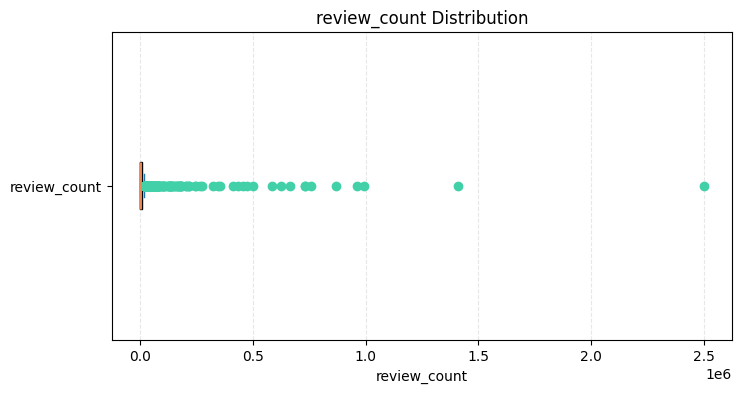

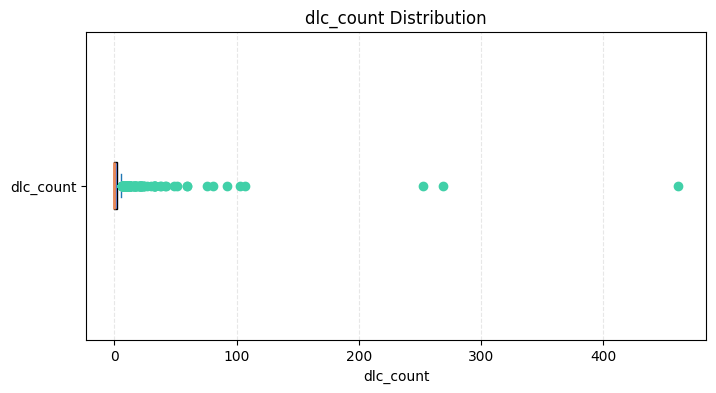

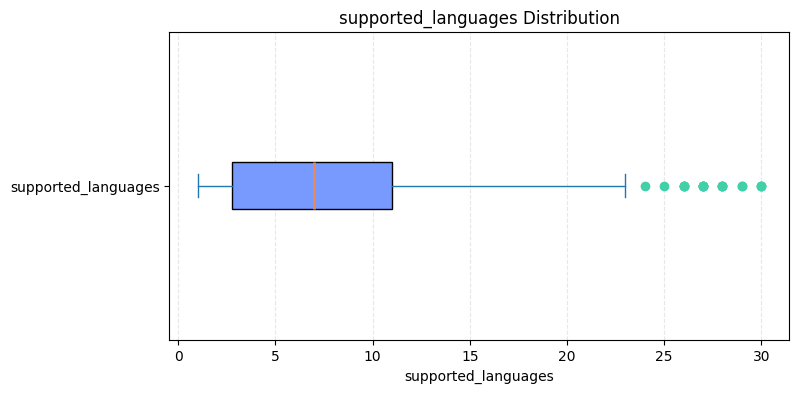

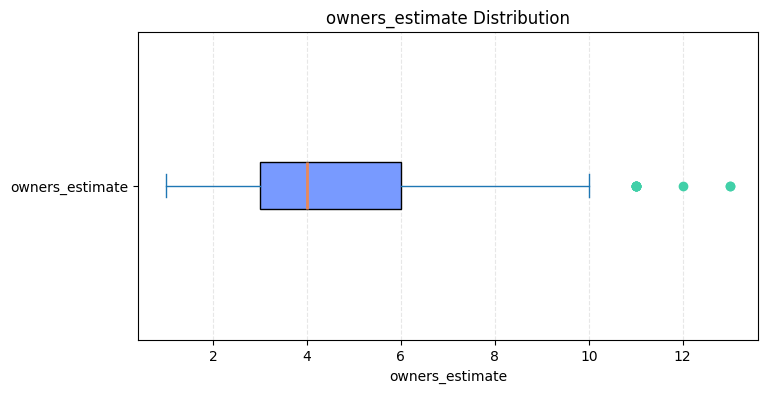

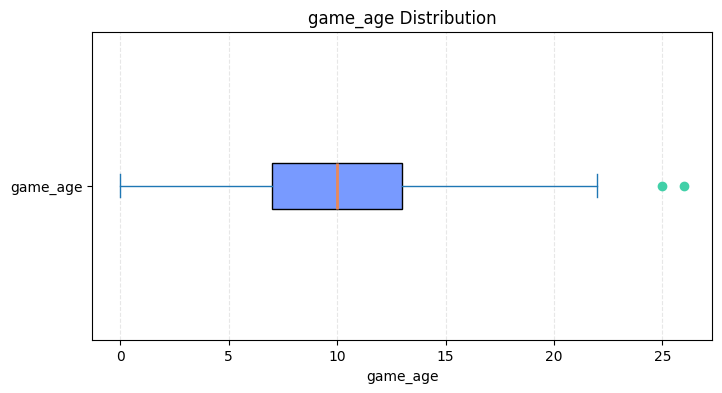

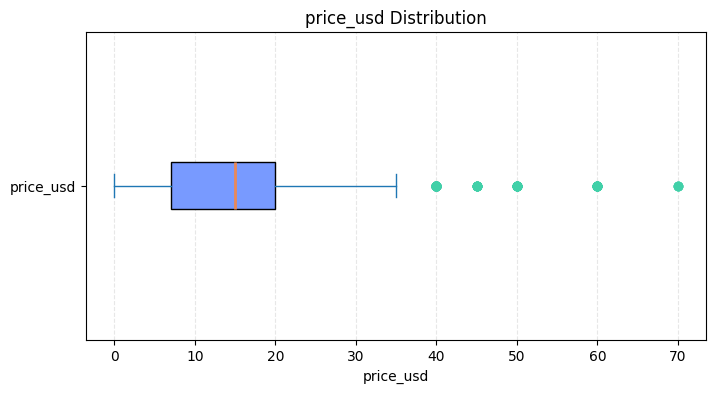

In [14]:


cols_to_check = [
    'review_count',
    'dlc_count',
    'supported_languages',
    'owners_estimate',
    'game_age',
    'price_usd'
]

for col in cols_to_check:
    if col in df.columns:
        df[col].plot(
            kind='box',
            title=f'{col} Distribution',
            vert=False,
            figsize=(8, 4),
            patch_artist=True,
            boxprops=dict(facecolor='#789AFF'),
            medianprops=dict(color='#EA8958', linewidth=2),
            flierprops=dict(marker='o', markersize=6,
                            markerfacecolor='#41D0A8',
                            markeredgecolor='#41D0A8')
        )

        plt.xlabel(col)
        plt.grid(axis='x', linestyle='--', alpha=0.3)
        plt.show()

#Dealing with outlier 1  (DLC)

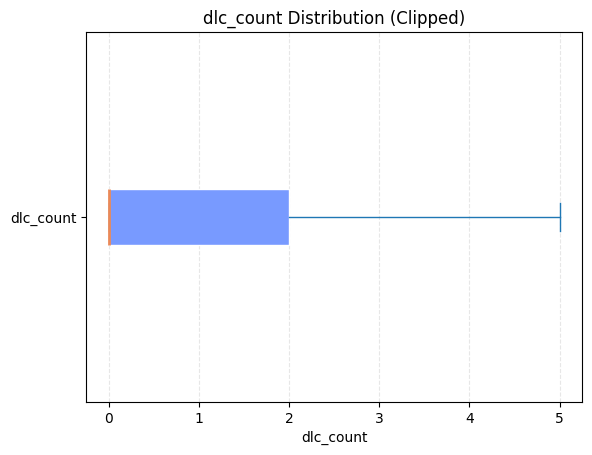

In [15]:


df_clip = df.copy()

col = 'dlc_count'

# fill missing values first (important)
df_clip[col] = df_clip[col].fillna(df_clip[col].median())

# IQR method
Q1 = df_clip[col].quantile(0.25)
Q3 = df_clip[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# clip values
df_clip[col] = df_clip[col].clip(lower=lower_bound, upper=upper_bound)

# keep it integer
df_clip[col] = df_clip[col].round().astype(int)

df_clip['dlc_count'].plot(
    kind='box',
    title='dlc_count Distribution (Clipped)',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#789AFF', color="#FFFFFF"),
    medianprops=dict(color='#EA8958', linewidth=2),
    flierprops=dict(marker='o', markersize=6,
                    markerfacecolor='#41D0A8',
                    markeredgecolor='#41D0A8')
)

plt.xlabel('dlc_count')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()
# The boxplot shows 8 as an outlier, but this is  because our data is heavily skewed
# since most games have 0 DLCs which makes the IQR very small and the upper whisker ends early.
# The 164 games with 8 DLCs are completely legitimate data points, not true outliers.
# As we move forward and apply further transformations this will be resolved.

#Dealing with Outliers Price

In [16]:
print(df['price_usd'].describe())#checking the min max and upper and lower quartiles of the feature
# i wont clip Price as its max value is a real industry standard number for new games no extreme vaues like 200-999

count    1400.000000
mean       15.652843
std        12.711473
min         0.000000
25%         6.990000
50%        14.990000
75%        19.990000
max        69.990000
Name: price_usd, dtype: float64


#Dealing with outliers Game Age

In [17]:
df['game_age'].describe()

,game_age
count,1400.000000
mean,9.938571
std,4.675971
min,0.000000
25%,7.000000
50%,10.000000
75%,13.000000
max,26.000000


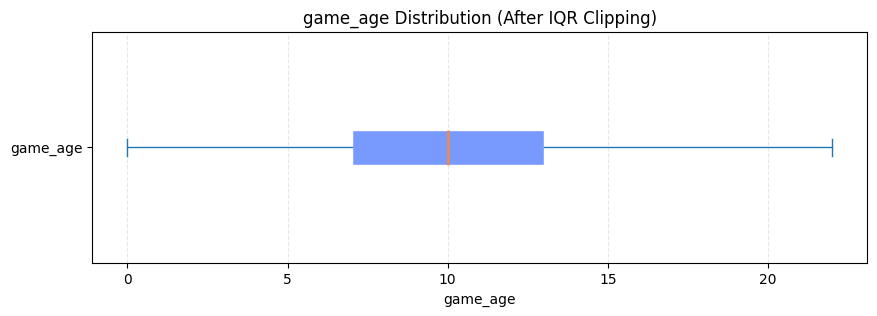

In [18]:

# 1. Calculate bounds and clip game_age
Q1_age = df['game_age'].quantile(0.25)
Q3_age = df['game_age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
upper_bound_age = Q3_age + 1.5 * IQR_age

df['game_age'] = df['game_age'].clip(upper=upper_bound_age)

# 2. Plot game_age
plt.figure(figsize=(10, 3))
df['game_age'].plot(
    kind='box',
    title='game_age Distribution (After IQR Clipping)',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#789AFF', color="#FFFFFF"),
    medianprops=dict(color='#EA8958', linewidth=2),
    flierprops=dict(marker='o', markersize=6,
                    markerfacecolor='#41D0A8',
                    markeredgecolor='#41D0A8')
)

plt.xlabel('game_age')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

##Dealing with owners_estimate

In [19]:
df['owners_estimate'].describe()
# values 11–13 represent the upper range of owners_estimate distribution
# transformations (e.g., scaling) will rescale values but will not remove them

,owners_estimate
count,1400.000000
mean,4.451429
std,2.272799
min,1.000000
25%,3.000000
50%,4.000000
75%,6.000000
max,13.000000


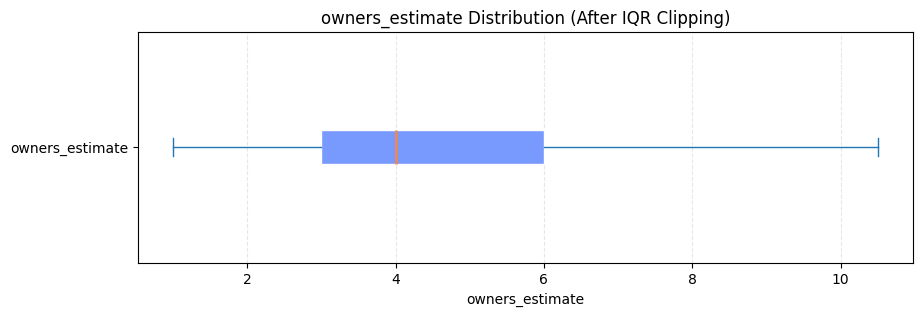

In [20]:
# 1. Calculate bounds and clip owners_estimate
Q1_owners = df['owners_estimate'].quantile(0.25)
Q3_owners = df['owners_estimate'].quantile(0.75)
IQR_owners = Q3_owners - Q1_owners
upper_bound_owners = Q3_owners + 1.5 * IQR_owners

df['owners_estimate'] = df['owners_estimate'].clip(upper=upper_bound_owners)

# 2. Plot owners_estimate
plt.figure(figsize=(10, 3))
df['owners_estimate'].plot(
    kind='box',
    title='owners_estimate Distribution (After IQR Clipping)',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#789AFF', color="#FFFFFF"),
    medianprops=dict(color='#EA8958', linewidth=2),
    flierprops=dict(marker='o', markersize=6,
                    markerfacecolor='#41D0A8',
                    markeredgecolor='#41D0A8')
)

plt.xlabel('owners_estimate')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

##Dealing with supported languages

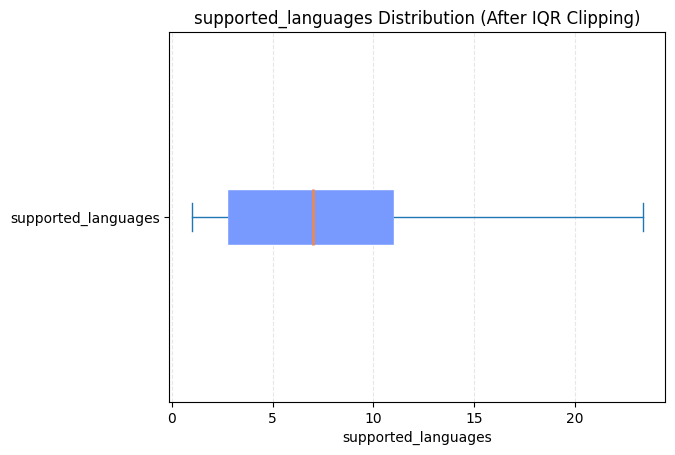

In [21]:

# make a copy so original data is preserved
df_clip = df.copy()

# ---- IQR CLIPPING ----
Q1 = df_clip['supported_languages'].quantile(0.25)
Q3 = df_clip['supported_languages'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clip['supported_languages'] = df_clip['supported_languages'].clip(lower=lower, upper=upper)

df_clip['supported_languages'].plot(
    kind='box',
    title='supported_languages Distribution (After IQR Clipping)',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#789AFF', color="#FFFFFF"),
    medianprops=dict(color='#EA8958', linewidth=2),
    flierprops=dict(marker='o', markersize=6,
                    markerfacecolor='#41D0A8',
                    markeredgecolor='#41D0A8')
)

plt.xlabel('supported_languages')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

#Dealing with outlier 4  review count

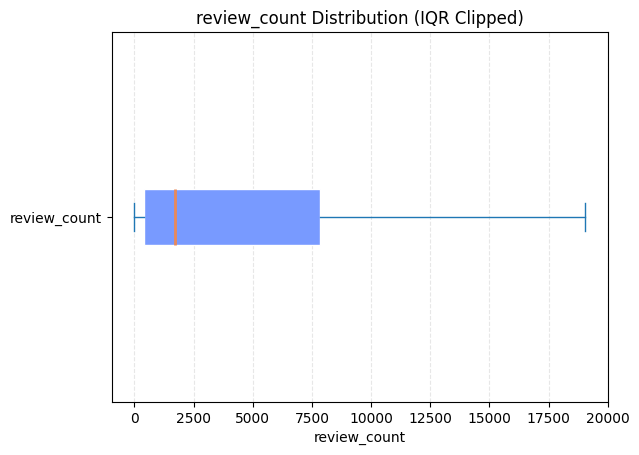

In [22]:
df_clip = df.copy()

Q1 = df_clip['review_count'].quantile(0.25)
Q3 = df_clip['review_count'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clip['review_count'] = df_clip['review_count'].clip(lower=lower, upper=upper)

df_clip['review_count'].plot(
    kind='box',
    title='review_count Distribution (IQR Clipped)',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#789AFF', color="#FFFFFF"),
    medianprops=dict(color='#EA8958', linewidth=2),
    flierprops=dict(marker='o', markersize=6,
                    markerfacecolor='#41D0A8',
                    markeredgecolor='#41D0A8')
)

plt.xlabel('review_count')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

##Encoding categorial Variables (Genre) Using onehotencoder

In [23]:
# 1. Create dummy columns for 'genres'
genre_dummies = pd.get_dummies(df_clip['genres'], prefix='Genre', drop_first=True, dtype=int)

print('Genre dummy columns created:')
print(genre_dummies.head())

# 2. Concatenate the new dummy columns to the main DataFrame
df_clip = pd.concat([df_clip, genre_dummies], axis=1)

# 3. Strategic Drop: Remove the original 'genres' column
df_clip.drop(columns=['genres'], inplace=True)

print("\n--- Final Preprocessed DataFrame Head ---")
df_clip.head()

Genre dummy columns created:
   Genre_Adventure  Genre_Casual  Genre_Free To Play  Genre_Indie  \
0                1             0                   0            0   
1                1             0                   0            0   
2                0             0                   0            0   
3                1             0                   0            0   
4                1             0                   0            0   

   Genre_Massively Multiplayer  Genre_RPG  Genre_Racing  Genre_Simulation  \
0                            0          0             0                 0   
1                            0          0             0                 0   
2                            0          0             0                 0   
3                            0          0             0                 0   
4                            0          0             0                 0   

   Genre_Sports  Genre_Strategy  Genre_Violent  
0             0               0             

,price_usd,is_free,coming_soon,early_access,review_count,dlc_count,required_age,windows,mac,linux,...,Genre_Casual,Genre_Free To Play,Genre_Indie,Genre_Massively Multiplayer,Genre_RPG,Genre_Racing,Genre_Simulation,Genre_Sports,Genre_Strategy,Genre_Violent
0,9.99,0,0,0,155.0,0,0.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,14.99,0,0,0,2267.0,2,0.0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,14.99,0,0,0,8772.0,5,0.0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
3,19.99,0,0,0,2344.0,1,0.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,29.99,0,0,0,3143.0,0,0.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


#Applying Feature Transformations

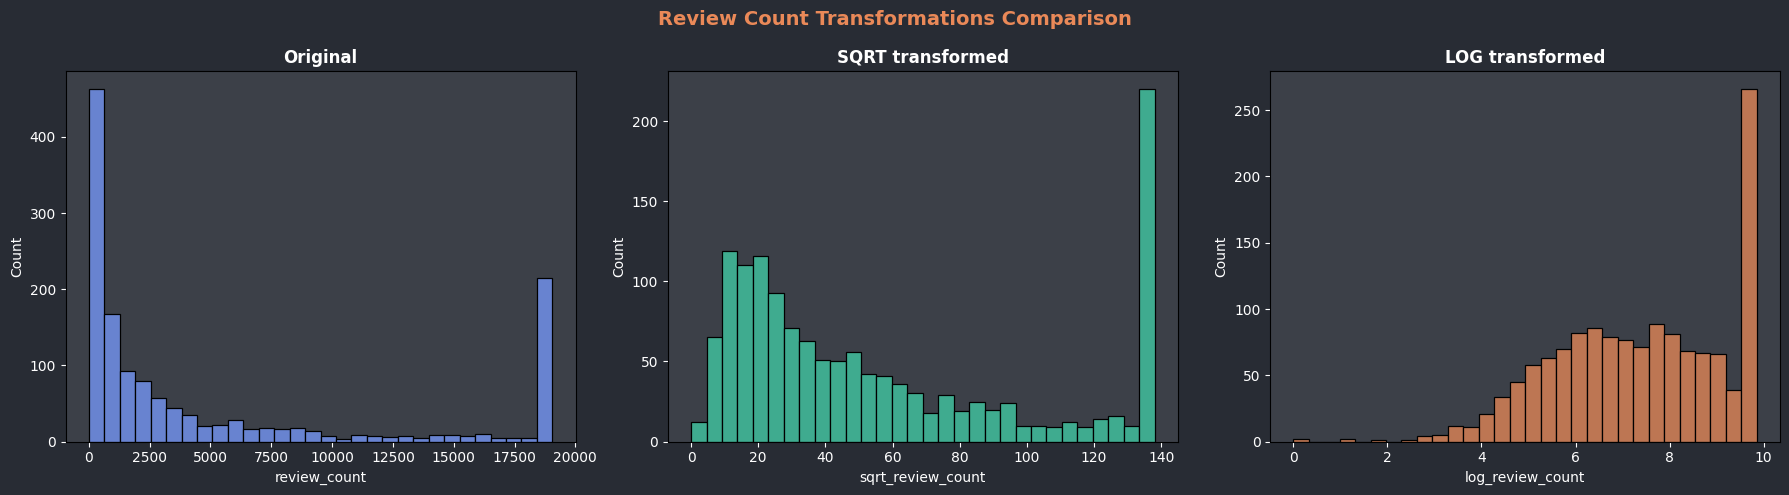

In [24]:
df_clip['sqrt_review_count'] = np.sqrt(df_clip['review_count'])
df_clip['log_review_count']  = np.log1p(df_clip['review_count'])



fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.set_facecolor('#282C34')

sns.histplot(df_clip['review_count'],      ax=axes[0], color='#789AFF', bins=30)
sns.histplot(df_clip['sqrt_review_count'], ax=axes[1], color='#41D0A8', bins=30)
sns.histplot(df_clip['log_review_count'],  ax=axes[2], color='#EA8958', bins=30)

axes[0].set_title('Original', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('SQRT transformed', color='white', fontsize=12, fontweight='bold')
axes[2].set_title('LOG transformed', color='white', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#3C4048')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

plt.suptitle('Review Count Transformations Comparison',
             color='#EA8958', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#We can clearly see that the log transformed is the closest to normal distrubituon so we use it


In [25]:
df_clip.drop(columns=['sqrt_review_count', 'review_count'], inplace=True, axis = 1)

#Applying transformations for Price

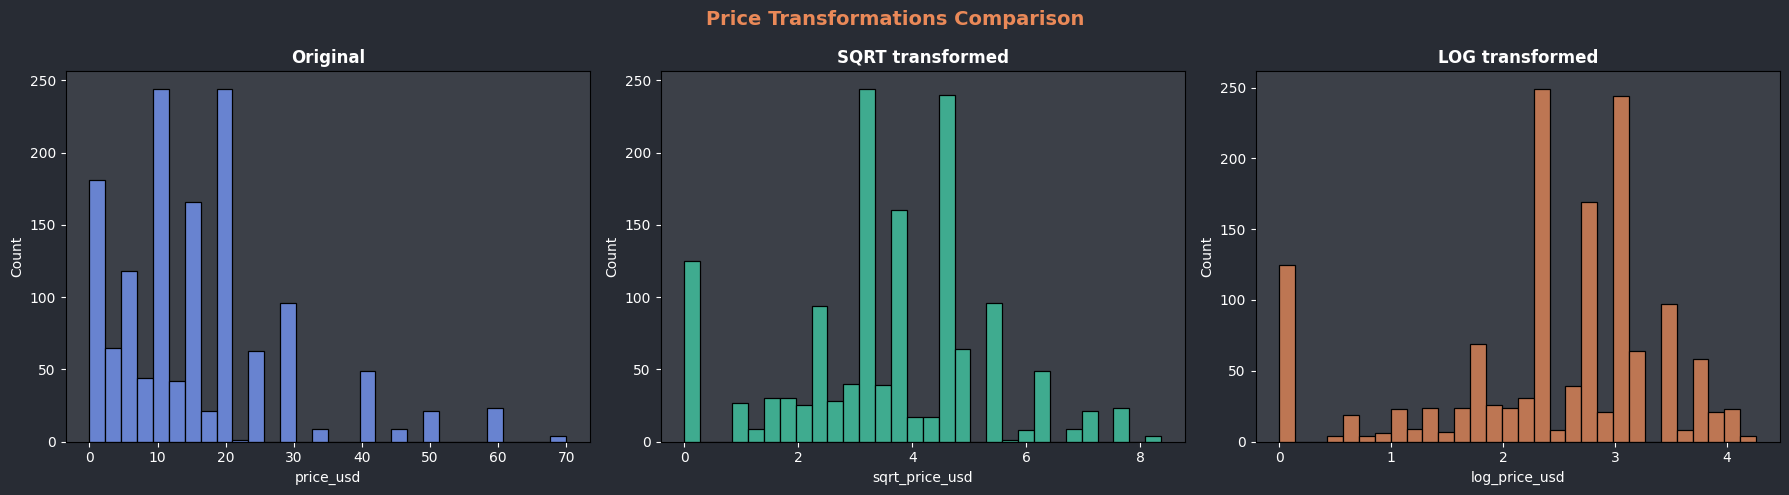

In [26]:
df_clip['sqrt_price_usd'] = np.sqrt(df_clip['price_usd'])
df_clip['log_price_usd']  = np.log1p(df_clip['price_usd'])


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.set_facecolor('#282C34')

sns.histplot(df_clip['price_usd'],      ax=axes[0], color='#789AFF', bins=30)
sns.histplot(df_clip['sqrt_price_usd'], ax=axes[1], color='#41D0A8', bins=30)
sns.histplot(df_clip['log_price_usd'],  ax=axes[2], color='#EA8958', bins=30)

axes[0].set_title('Original', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('SQRT transformed', color='white', fontsize=12, fontweight='bold')
axes[2].set_title('LOG transformed', color='white', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#3C4048')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

plt.suptitle('Price Transformations Comparison',
             color='#EA8958', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#SQRT Is the lest skewed so we use it and drop the others

In [27]:
df_clip.drop(columns=[ 'price_usd','log_price_usd'], inplace=True, axis = 1 )

#Applying transformations for Owners estimate

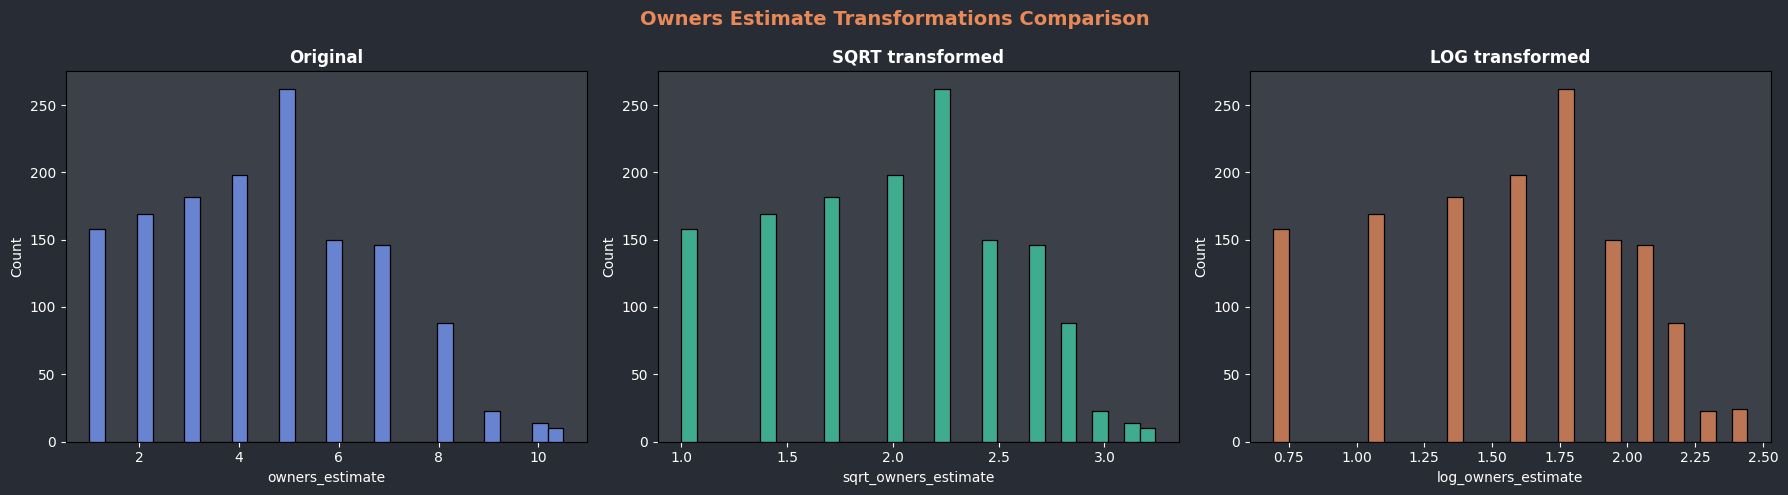

In [28]:
df_clip['sqrt_owners_estimate'] = np.sqrt(df_clip['owners_estimate'])
df_clip['log_owners_estimate']  = np.log1p(df_clip['owners_estimate'])



fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.set_facecolor('#282C34')

sns.histplot(df_clip['owners_estimate'],       ax=axes[0], color='#789AFF', bins=30)
sns.histplot(df_clip['sqrt_owners_estimate'],  ax=axes[1], color='#41D0A8', bins=30)
sns.histplot(df_clip['log_owners_estimate'],   ax=axes[2], color='#EA8958', bins=30)

axes[0].set_title('Original', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('SQRT transformed', color='white', fontsize=12, fontweight='bold')
axes[2].set_title('LOG transformed', color='white', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#3C4048')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

plt.suptitle('Owners Estimate Transformations Comparison',
             color='#EA8958', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#The sqrt is the best so we stick with it

In [29]:
df_clip.drop(columns=['owners_estimate', 'log_owners_estimate'], inplace=True, axis = 1)

#Now for the last 1 dlc_count

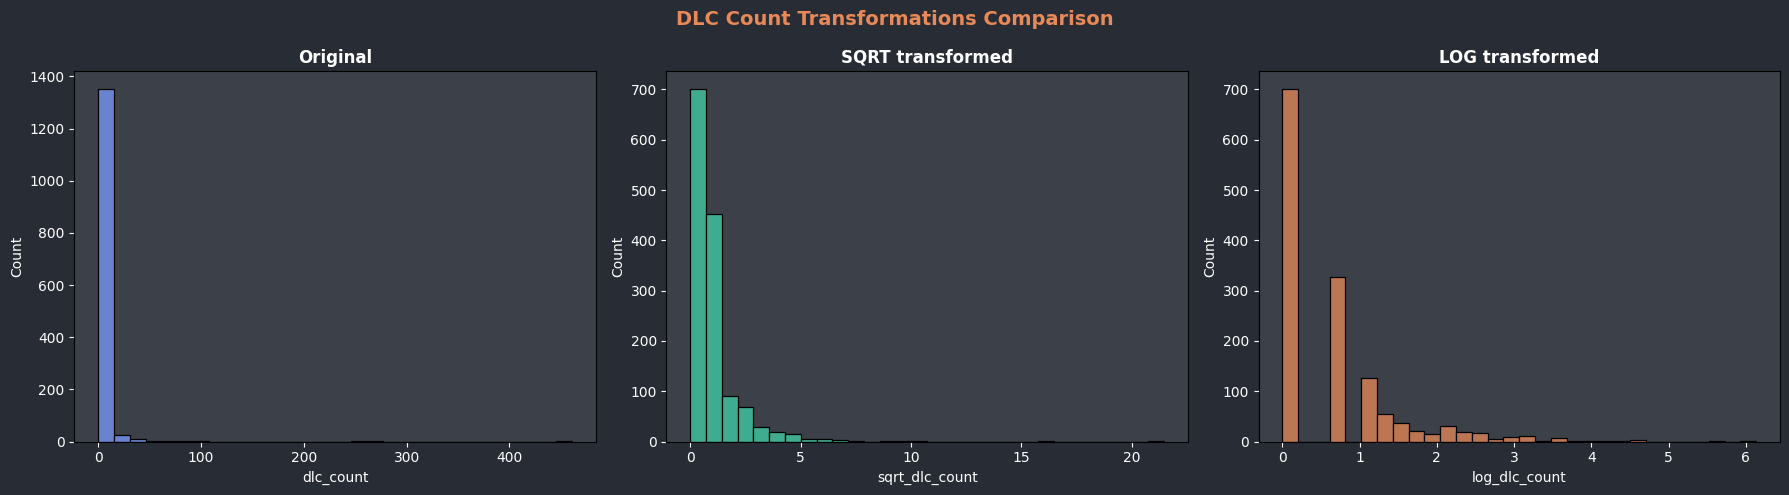

In [30]:
df_clip['sqrt_dlc_count'] = np.sqrt(df_clip['dlc_count'])
df_clip['log_dlc_count']  = np.log1p(df_clip['dlc_count'])



fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.set_facecolor('#282C34')

sns.histplot(df_clip['dlc_count'],      ax=axes[0], color='#789AFF', bins=30)
sns.histplot(df_clip['sqrt_dlc_count'], ax=axes[1], color='#41D0A8', bins=30)
sns.histplot(df_clip['log_dlc_count'],  ax=axes[2], color='#EA8958', bins=30)

axes[0].set_title('Original', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('SQRT transformed', color='white', fontsize=12, fontweight='bold')
axes[2].set_title('LOG transformed', color='white', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#3C4048')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

plt.suptitle('DLC Count Transformations Comparison',
             color='#EA8958', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#They are all bad as most games have 0 dlc we will use sqrt



In [31]:
df_clip.drop(columns=['dlc_count', 'log_dlc_count'], inplace=True, errors='ignore')

#Transforming supported languages

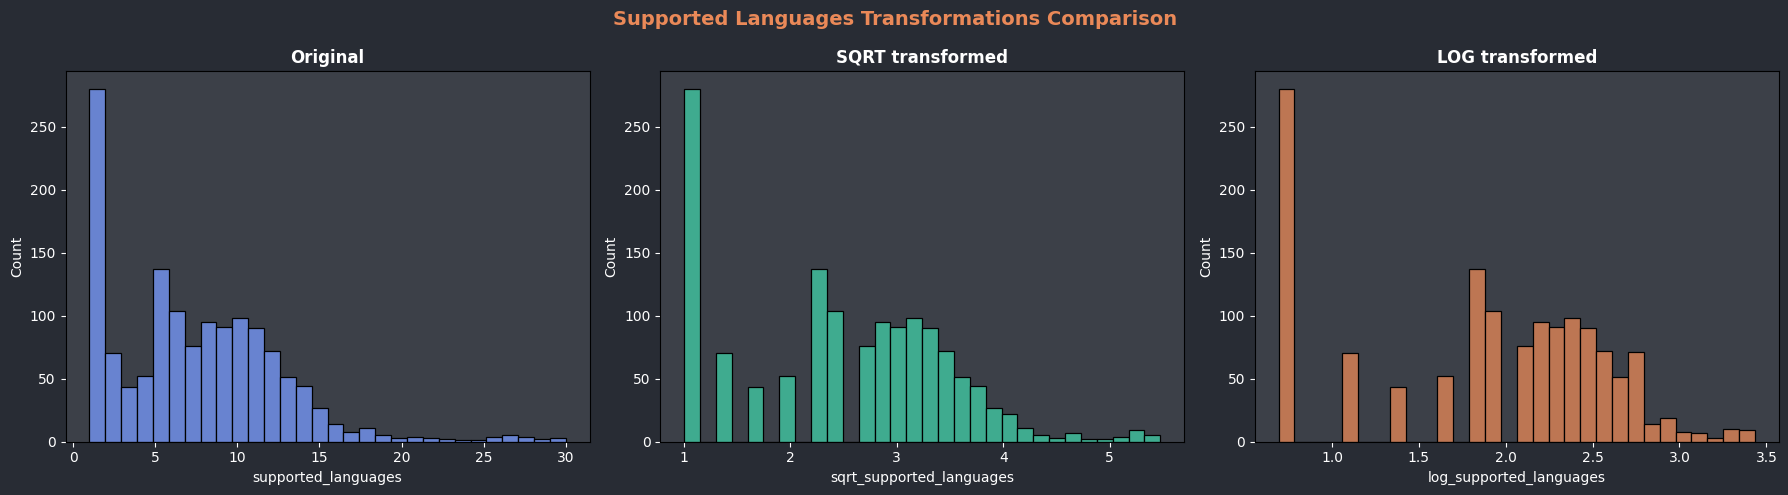

In [32]:
df_clip['sqrt_supported_languages'] = np.sqrt(df_clip['supported_languages'])
df_clip['log_supported_languages']  = np.log1p(df_clip['supported_languages'])


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.set_facecolor('#282C34')

sns.histplot(df_clip['supported_languages'],      ax=axes[0], color='#789AFF', bins=30)
sns.histplot(df_clip['sqrt_supported_languages'], ax=axes[1], color='#41D0A8', bins=30)
sns.histplot(df_clip['log_supported_languages'],  ax=axes[2], color='#EA8958', bins=30)

axes[0].set_title('Original', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('SQRT transformed', color='white', fontsize=12, fontweight='bold')
axes[2].set_title('LOG transformed', color='white', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#3C4048')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

plt.suptitle('Supported Languages Transformations Comparison',
             color='#EA8958', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#They are all bad as most games have 0 dlc we will use sqrt

In [33]:
df_clip.drop(columns=['supported_languages', 'log_supported_languages'], inplace=True, errors='ignore')

#Adding Visualization to look for patterns between variables

/tmp/ipykernel_1074/1532320820.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price_bin', y='success', data=df, ax=ax, palette='viridis')


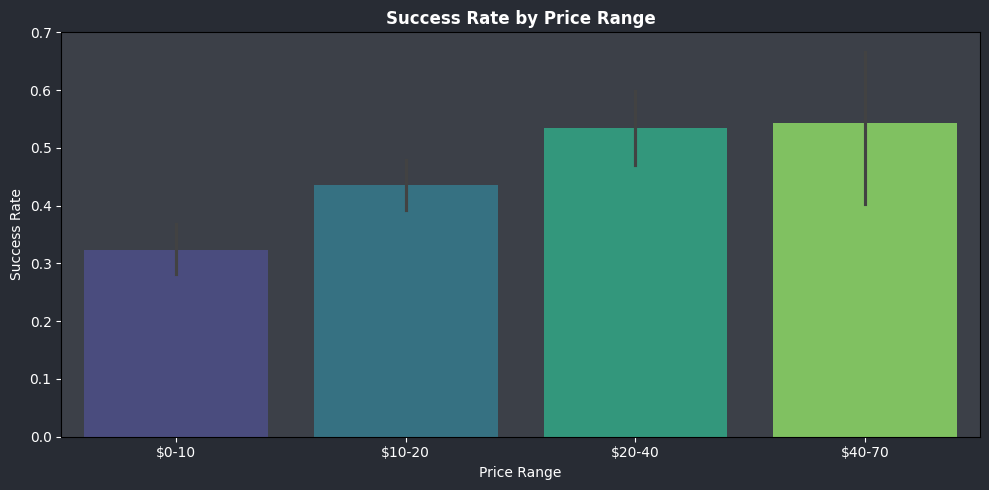

In [34]:

fig, ax = plt.subplots(figsize=(10, 5))
fig.set_facecolor('#282C34')

# Bin original price for readable labels
df['price_bin'] = pd.cut(
    df['price_usd'],
    bins=[0, 10, 20, 40, 70],
    labels=['$0-10', '$10-20', '$20-40', '$40-70']
)

sns.barplot(x='price_bin', y='success', data=df, ax=ax, palette='viridis')

ax.set_title('Success Rate by Price Range', color='white', fontweight='bold')
ax.set_ylabel('Success Rate', color='white')
ax.set_xlabel('Price Range', color='white')
ax.set_facecolor('#3C4048')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')

# Clean up temp column
df.drop(columns=['price_bin'], inplace=True, errors='ignore')

plt.tight_layout()
plt.show()

#Visualsing feature vs Target to identify patterns

/tmp/ipykernel_1074/1210690326.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='owners_label', y='success', data=df, ax=ax, palette='viridis', order=order_list)


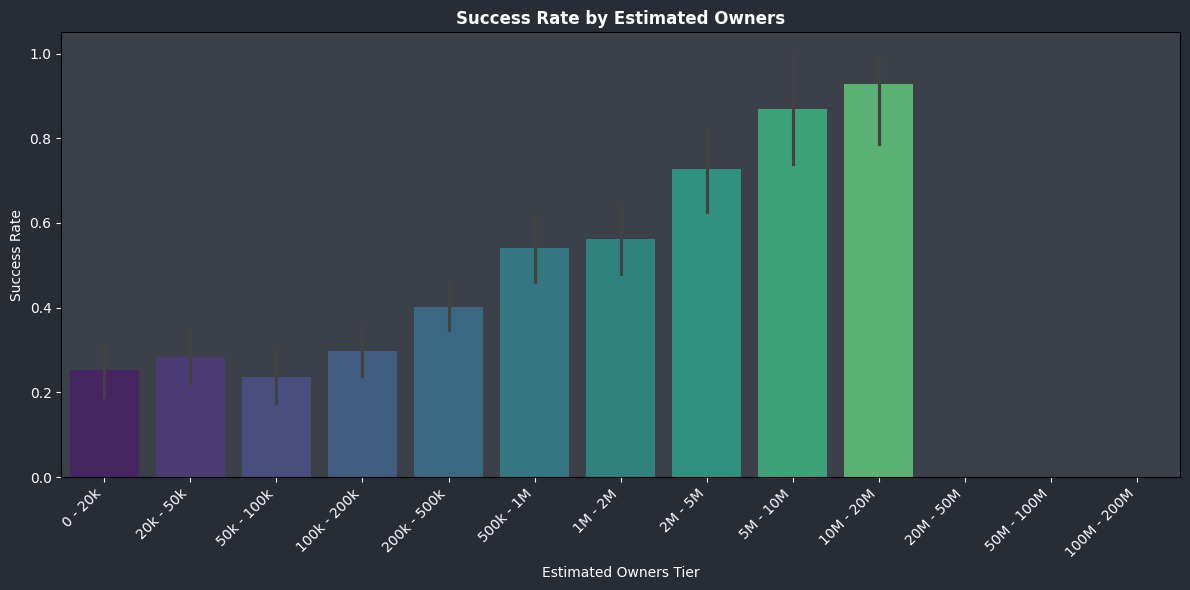

In [35]:
fig, ax = plt.subplots(figsize=(12, 6)) # Made slightly wider for long labels
fig.set_facecolor('#282C34')

# Create a mapping dictionary to turn your integers back into readable labels for the plot
label_map = {
    1: '0 - 20k',
    2: '20k - 50k',
    3: '50k - 100k',
    4: '100k - 200k',
    5: '200k - 500k',
    6: '500k - 1M',
    7: '1M - 2M',
    8: '2M - 5M',
    9: '5M - 10M',
    10: '10M - 20M',
    11: '20M - 50M',
    12: '50M - 100M',
    13: '100M - 200M'
}

# Create a temporary column for the plot using the label map
df['owners_label'] = df['owners_estimate'].map(label_map)

# We need to ensure the x-axis order is correct (1 to 13), so we pass the exact order
order_list = list(label_map.values())

# Plot the barplot using the new labels
sns.barplot(x='owners_label', y='success', data=df, ax=ax, palette='viridis', order=order_list)

ax.set_title('Success Rate by Estimated Owners', color='white', fontweight='bold')
ax.set_ylabel('Success Rate', color='white')
ax.set_xlabel('Estimated Owners Tier', color='white')
ax.set_facecolor('#3C4048')

# Rotate the x labels so they don't overlap
ax.tick_params(colors='white')
plt.xticks(rotation=45, ha='right')

ax.xaxis.label.set_color('white')

# Clean up temp column
df.drop(columns=['owners_label'], inplace=True, errors='ignore')

plt.tight_layout()
plt.show()

##Now for the Last step in EDA sccaling features

In [36]:
num_cols = ['sqrt_price_usd', 'log_review_count', 'sqrt_owners_estimate', 'sqrt_dlc_count', 'required_age', 'review_polarization', 'game_age', 'sqrt_supported_languages']

# features and target
X = df_clip[num_cols]
y = df_clip['success']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=18
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1120, 8)
Test shape: (280, 8)


In [37]:

scaler = StandardScaler()

# fit ONLY on training data
X_train = scaler.fit_transform(X_train)

# transform test using same scaler
X_test = scaler.transform(X_test)



In [38]:

# choose K
k = 28

# model
knn = KNeighborsClassifier(n_neighbors=k)

# train
knn.fit(X_train, y_train)

# predict
y_pred = knn.predict(X_test)

# evaluate
accuracy = metrics.accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9107142857142857


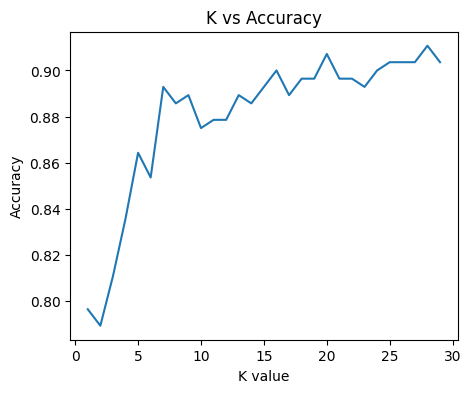

Best K: 28  |  Accuracy: 0.9107


In [39]:
score_list = []
k_range = range(1, 30)

for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    score_list.append(metrics.accuracy_score(y_test, pred_i))

plt.figure(figsize=(5, 4))
plt.plot(k_range, score_list)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

best_k = list(k_range)[score_list.index(max(score_list))]
print(f"Best K: {best_k}  |  Accuracy: {max(score_list):.4f}")

#Creating confusion matrix

In [40]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_prediction = knn.predict(X_test)

score = metrics.accuracy_score(y_test, y_prediction)
print('Accuracy score: ', score)

cm = metrics.confusion_matrix(y_test, y_prediction)
print(cm)

Accuracy score:  0.9107142857142857
[[161  11]
 [ 14  94]]


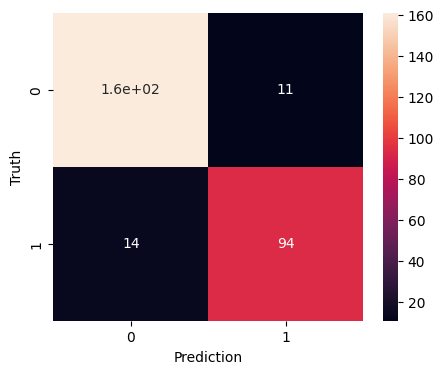

In [41]:
#plot the confusion matrix using the heatmap function from seaborn
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True)
plt.ylabel("Truth")
plt.xlabel("Prediction")
plt.show()

##91% ACC. is a relativly large number so we conduct a test to check for overfitting

In [42]:
#To verify that the model was not overfitting,
# the training and testing accuracies were compared.
# Overfitting would be indicated by a significantly higher training accuracy than testing accuracy.
# The observed gap between the two accuracies was used as a measure of the model's generalization performance.

# choose K
k = 28

knn = KNeighborsClassifier(n_neighbors=k)

# train model
knn.fit(X_train, y_train)

# predictions
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

# accuracy
train_acc = metrics.accuracy_score(y_train, y_train_pred)
test_acc  = metrics.accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)
print("Gap (Train - Test):", train_acc - test_acc)


Train Accuracy: 0.8544642857142857
Test Accuracy : 0.9107142857142857
Gap (Train - Test): -0.05625000000000002


##There is no signs of overfitting as the test accuracy is higher than training the performance on unseen data is better than on seen

#Adding correlation matrix to identify patterns between Features

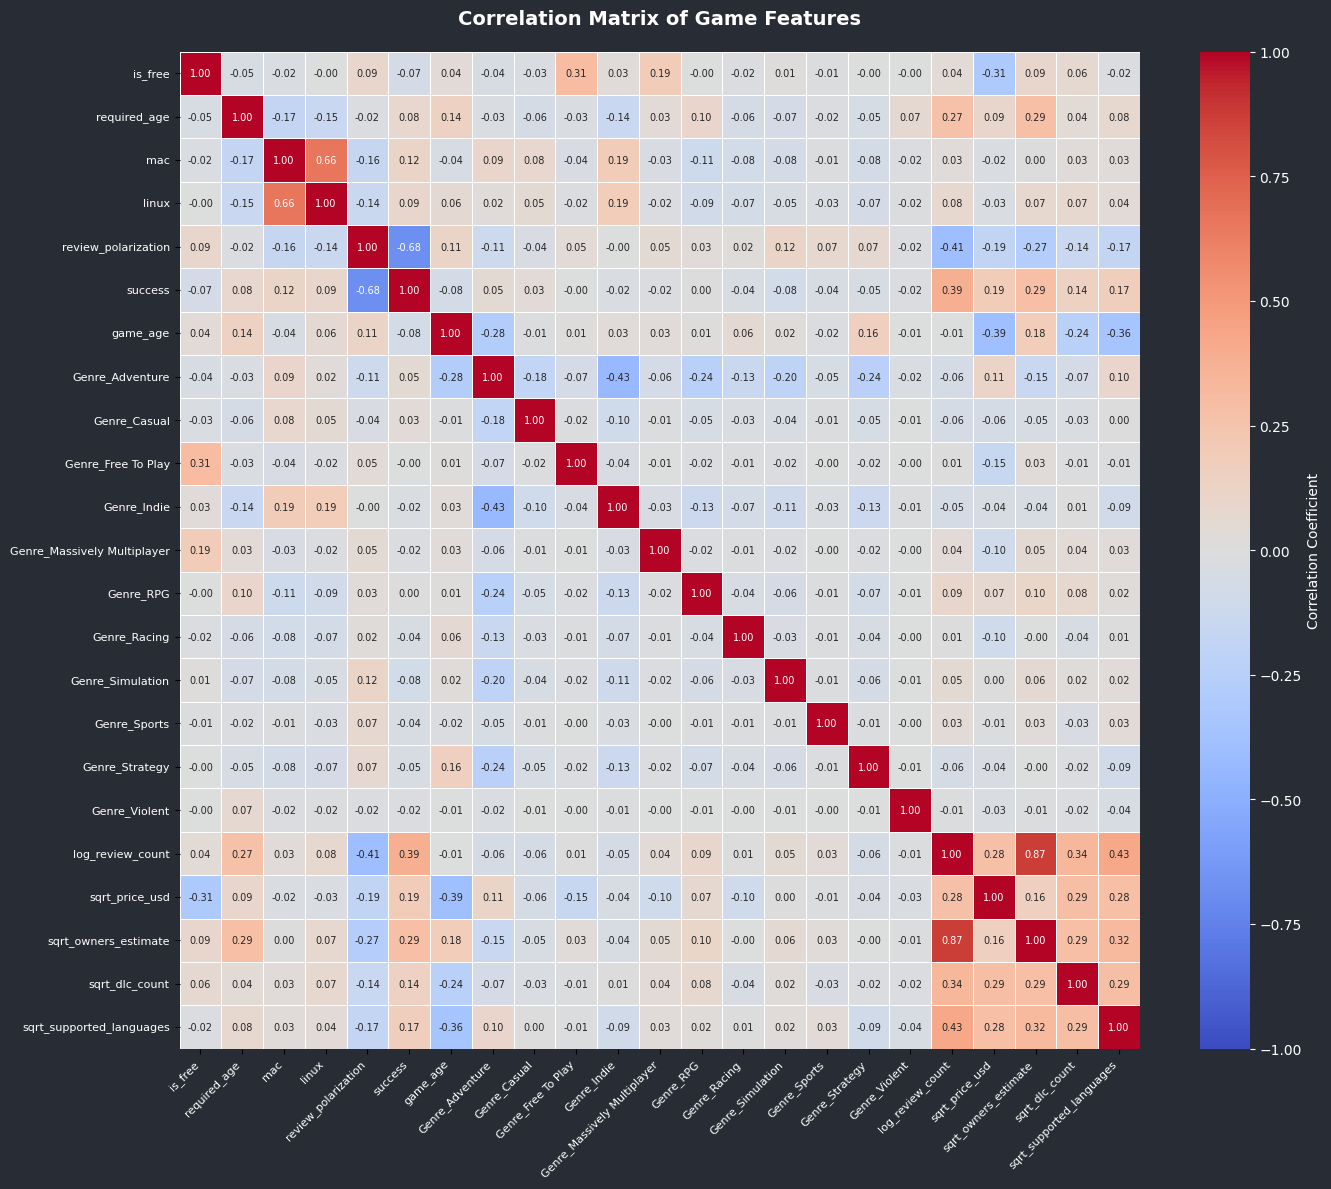

In [43]:


# 1. Filter out features with 0 variance (columns where all values are identical)
# This removes columns like coming_soon, early_access, and windows automatically.
df_filtered = df_clip.loc[:, df_clip.nunique() > 1]

# 2. Calculate the correlation matrix on the cleaned data
corr_matrix = df_filtered.corr()

# 3. Set up the figure with your dark background theme
fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#282C34')
ax.set_facecolor('#282C34')

# 4. Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'},
            annot_kws={"size": 7}, vmin=-1, vmax=1) # Added vmin/vmax to lock the scale properly

# 5. Style the titles, text, and labels so they are readable in dark mode
plt.title('Correlation Matrix of Game Features', color='white', fontsize=14, fontweight='bold', pad=20)
plt.xticks(color='white', rotation=45, ha='right', fontsize=8)
plt.yticks(color='white', rotation=0, fontsize=8)

# 6. Style the colorbar (legend) text
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(colors='white')
cbar.set_label('Correlation Coefficient', color='white')

plt.tight_layout()
plt.show()

##Part 2 Classification using logistic regression

In [44]:


# ── Create and train the model ───────────────────────────────────────────────
logreg = LogisticRegression()

logreg.fit(X_train, y_train)

# ── Predict on test set ──────────────────────────────────────────────────────
y_pred = logreg.predict(X_test)



#Finding accuracy of a model

In [45]:

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy on test set: {acc:.2%}")

print(
    f"That means the model got "
    f"{int(acc * len(y_test))} out of {len(y_test)} games right!"
)

Accuracy on test set: 88.93%
That means the model got 249 out of 280 games right!


In [46]:
y_train_pred_lr = logreg.predict(X_train)
y_test_pred_lr  = logreg.predict(X_test)

train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
test_acc_lr  = accuracy_score(y_test, y_test_pred_lr)

print(f"Logistic Regression Train Accuracy: {train_acc_lr:.4f}")
print(f"Logistic Regression Test Accuracy : {test_acc_lr:.4f}")
print(f"Gap (Train - Test): {train_acc_lr - test_acc_lr:.4f}")

Logistic Regression Train Accuracy: 0.8616
Logistic Regression Test Accuracy : 0.8893
Gap (Train - Test): -0.0277


### 4. Logistic Regression Decision Boundary

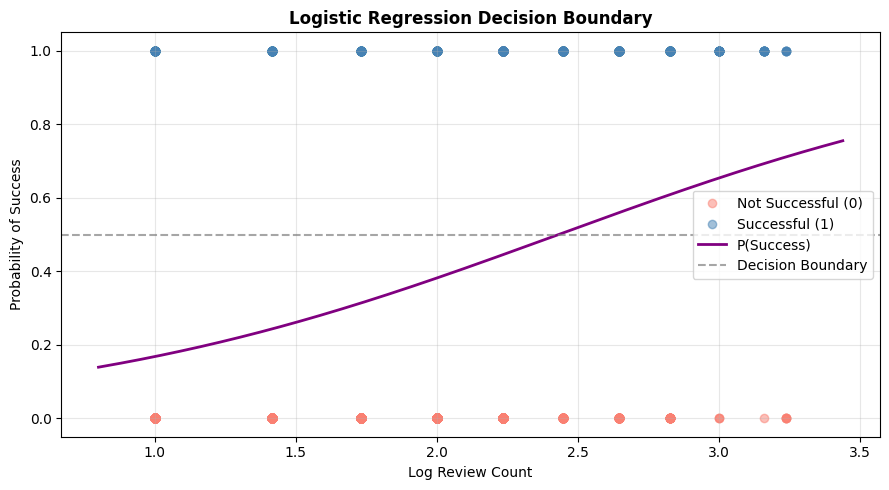

In [47]:
# ── Use one feature for visualization ────────────────────────────────────────
X_vis = df_clip[['sqrt_owners_estimate']]
y_vis = df_clip['success']

# ── Train Logistic Regression on ONE feature ─────────────────────────────────
logreg_vis = LogisticRegression()
logreg_vis.fit(X_vis, y_vis)

# ── Create smooth x-axis values ──────────────────────────────────────────────
x_range = np.linspace(
    X_vis.min().values[0] - 0.2,
    X_vis.max().values[0] + 0.2,
    300
)

# ── Wrap in DataFrame to match training feature names ────────────────────────
x_range_df = pd.DataFrame(x_range, columns=['sqrt_owners_estimate'])

# probability of class 1
prob = logreg_vis.predict_proba(x_range_df)[:, 1]

# ── White background ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.set_facecolor('white')
ax.set_facecolor('white')

# scatter actual data
ax.scatter(X_vis[y_vis == 0], y_vis[y_vis == 0],
           color='salmon', label='Not Successful (0)', alpha=0.5)

ax.scatter(X_vis[y_vis == 1], y_vis[y_vis == 1],
           color='steelblue', label='Successful (1)', alpha=0.5)

# probability curve
ax.plot(x_range, prob, color='purple', linewidth=2, label='P(Success)')

# decision threshold
ax.axhline(0.5, color='gray', linestyle='--',
           alpha=0.7, label='Decision Boundary')

# labels and title
ax.set_title('Logistic Regression Decision Boundary',
             fontweight='bold')

ax.set_xlabel('Log Review Count')
ax.set_ylabel('Probability of Success')

# make axes/ticks black for white background
ax.tick_params(colors='black')

ax.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
from IPython.display import display, HTML
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve)
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import json

# ── Gather stats for a given model ─────────────────────────────────────────────
def get_model_stats(y_true, y_pred, model, X):
    proba   = model.predict_proba(X)[:, 1]
    cm      = confusion_matrix(y_true, y_pred).tolist()
    fpr, tpr, _ = roc_curve(y_true, proba)
    report  = classification_report(y_true, y_pred, output_dict=True)
    idx = np.linspace(0, len(fpr)-1, 40, dtype=int)
    return {
        "accuracy":  round(accuracy_score(y_true, y_pred) * 100, 2),
        "precision": round(precision_score(y_true, y_pred) * 100, 2),
        "recall":    round(recall_score(y_true, y_pred) * 100, 2),
        "f1":        round(f1_score(y_true, y_pred) * 100, 2),
        "auc":       round(roc_auc_score(y_true, proba) * 100, 2),
        "cm":        cm,
        "fpr":       [round(float(fpr[i]), 4) for i in idx],
        "tpr":       [round(float(tpr[i]), 4) for i in idx],
        "correct":   int((np.array(y_true) == np.array(y_pred)).sum()),
        "total":     int(len(y_true)),
        "report":    report,
    }

# ── Sweep ALL K values 1–30 ──────────────────────────────────────────────────
K_MIN, K_MAX, K_DEFAULT = 1, 30, 28

k_stats = {}
for k in range(K_MIN, K_MAX + 1):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    y_pred_k = knn_k.predict(X_test)
    k_stats[str(k)] = get_model_stats(y_test.values, y_pred_k, knn_k, X_test)

# ── LR stats ─────────────────────────────────────────────────────────────────
y_pred_lr = logreg.predict(X_test)
lr_stats  = get_model_stats(y_test.values, y_pred_lr, logreg, X_test)

stats = {
    "KNN":       k_stats,
    "LR":        lr_stats,
    "K_MIN":     K_MIN,
    "K_MAX":     K_MAX,
    "K_DEFAULT": K_DEFAULT,
    "TOTAL":     int(len(y_test)),
}

stats_json = json.dumps(stats)

# ── Red Dead Redemption Themed HTML Dashboard ─────────────────────────────────
html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<link href="https://fonts.googleapis.com/css2?family=Rye&family=Courier+Prime:wght@400;700&display=swap" rel="stylesheet">
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.0/chart.umd.min.js"></script>
<style>
  *{{box-sizing:border-box;margin:0;padding:0}}
  :root{{
    --bg:#0c0806;--panel:#18100c;--panel2:#140e0a;--wood:#3d2817;
    --parchment:#dcd0c0;--sepia:#c9a959;--gold:#d4af37;--rust:#8b4513;
    --blood:#6b1a1a;--iron:#5a5a5a;--text:#e8dcc8;--muted:#8a7e6b;--border:#2a1f17;
  }}
  body{{font-family:'Courier Prime',monospace;background:var(--bg);color:var(--text);
    padding:24px;min-height:100vh;position:relative;overflow-x:hidden;}}
  body::before{{content:"";position:fixed;top:0;left:0;right:0;bottom:0;
    background:repeating-linear-gradient(90deg,rgba(61,40,23,.08) 0px,transparent 1px,transparent 3px),
               repeating-linear-gradient(0deg,rgba(61,40,23,.05) 0px,transparent 1px,transparent 4px);
    pointer-events:none;z-index:9999;}}
  body::after{{content:"";position:fixed;top:0;left:0;right:0;bottom:0;
    background:radial-gradient(circle at center,transparent 50%,rgba(12,8,6,.8) 100%);
    pointer-events:none;z-index:9998;}}

  /* Header */
  .header-wrapper{{position:relative;width:100%;min-height:280px;margin-bottom:20px;}}
  .logo-wrap{{text-align:center;padding-top:15px;position:relative;z-index:20;}}
  .logo-img{{height:140px;max-width:90vw;filter:drop-shadow(0 0 25px rgba(212,175,55,.5));transition:transform .3s;}}
  .logo-img:hover{{transform:scale(1.05);}}
  .wanted-stamp{{font-family:'Rye',cursive;font-size:16px;color:var(--blood);border:3px double var(--blood);
    padding:6px 16px;display:inline-block;transform:rotate(-5deg);letter-spacing:4px;
    text-transform:uppercase;opacity:.9;text-shadow:0 0 8px rgba(107,26,26,.6);margin-top:8px;}}
  .revolver-deco{{position:absolute;z-index:10;opacity:.40;pointer-events:none;
    filter:sepia(.4) drop-shadow(0 0 15px rgba(0,0,0,.6));}}
  .revolver-left{{top:40px;left:-35px;width:360px;transform:rotate(25deg) scaleX(-1);}}
  .revolver-right{{top:40px;right:-35px;width:360px;transform:rotate(-25deg);}}
  .wanted-poster{{position:absolute;top:5px;right:10px;width:200px;z-index:1;
    background:var(--parchment);padding:10px;border:4px solid var(--wood);
    box-shadow:0 10px 30px rgba(0,0,0,.7);transform:rotate(3deg);
    transition:transform .3s,box-shadow .3s;}}
  .wanted-poster:hover{{transform:rotate(0deg) scale(1.05);box-shadow:0 15px 40px rgba(0,0,0,.85);z-index:25;}}
  .wanted-poster img{{width:100%;filter:sepia(.3) contrast(1.15);display:block;border:1px solid var(--wood);}}
  .wanted-label{{font-family:'Rye',cursive;font-size:18px;color:var(--blood);text-align:center;
    margin-top:6px;letter-spacing:2px;text-transform:uppercase;
    border-top:3px double var(--blood);border-bottom:3px double var(--blood);padding:2px 0;}}
  .wanted-reward{{font-family:'Courier Prime',monospace;font-size:10px;color:var(--wood);
    text-align:center;margin-top:4px;letter-spacing:1px;font-weight:700;}}
  h1{{font-family:'Rye',cursive;font-size:28px;font-weight:400;color:var(--gold);
    text-transform:uppercase;letter-spacing:4px;
    text-shadow:0 0 15px rgba(212,175,55,.3),2px 2px 4px rgba(0,0,0,.8);
    margin-top:15px;margin-bottom:6px;text-align:center;position:relative;z-index:20;}}
  .subtitle{{font-family:'Courier Prime',monospace;font-size:13px;color:var(--muted);
    margin-bottom:10px;letter-spacing:2px;text-transform:uppercase;
    text-align:center;position:relative;z-index:20;}}
  .subtitle::before,.subtitle::after{{content:" ◆ ";color:var(--rust);}}
  .gang-watermark{{position:fixed;bottom:0;left:0;width:100%;height:380px;
    background:url('https://kimi-web-img.moonshot.cn/img/static.wikia.nocookie.net/c72eab517386241744997e8c3178cdd6d197a052') center bottom no-repeat;
    background-size:cover;opacity:.15;pointer-events:none;z-index:1;
    mask-image:linear-gradient(to top,rgba(0,0,0,1) 0%,transparent 100%);
    -webkit-mask-image:linear-gradient(to top,rgba(0,0,0,1) 0%,transparent 100%);}}

  /* Model tabs */
  .toggle-wrap{{display:flex;gap:0;margin:24px auto;background:var(--panel);
    border:2px solid var(--border);width:fit-content;position:relative;z-index:10;
    box-shadow:0 4px 20px rgba(0,0,0,.5);}}
  .toggle-btn{{padding:12px 28px;border:none;cursor:pointer;font-family:'Rye',cursive;
    font-size:13px;font-weight:400;text-transform:uppercase;letter-spacing:2px;
    transition:all .3s;color:var(--muted);background:transparent;
    border-right:1px solid var(--border);position:relative;}}
  .toggle-btn:last-child{{border-right:none;}}
  .toggle-btn:hover{{color:var(--gold);text-shadow:0 0 8px rgba(212,175,55,.4);}}
  .toggle-btn.active{{background:linear-gradient(180deg,rgba(139,69,19,.3) 0%,rgba(139,69,19,.1) 100%);
    color:var(--gold);text-shadow:0 0 12px rgba(212,175,55,.5);border-bottom:3px solid var(--rust);}}
  .toggle-btn.active::before{{content:"◆";position:absolute;left:8px;font-size:10px;color:var(--gold);}}

  /* ═══════════════════════════════════════════
     K SLIDER PANEL
  ═══════════════════════════════════════════ */
  .k-selector-panel{{
    background:var(--panel);border:2px solid var(--border);
    padding:28px 28px 22px;margin-bottom:24px;position:relative;
    z-index:10;box-shadow:0 4px 15px rgba(0,0,0,.4);
  }}
  .k-selector-panel::before{{
    content:'[KNN CONFIG]';position:absolute;top:-1px;left:24px;
    background:var(--rust);color:var(--parchment);font-family:'Courier Prime',monospace;
    font-size:9px;padding:3px 10px;letter-spacing:3px;font-weight:700;text-transform:uppercase;
    box-shadow:0 2px 10px rgba(139,69,19,.4);
  }}

  /* top row: label + big K display + mini stats */
  .k-top-row{{display:flex;align-items:center;gap:28px;margin-bottom:20px;flex-wrap:wrap;}}
  .k-title{{font-family:'Rye',cursive;font-size:13px;color:var(--sepia);
    text-transform:uppercase;letter-spacing:2px;white-space:nowrap;}}

  .k-display{{
    display:flex;align-items:baseline;gap:10px;
    background:var(--panel2);border:2px solid var(--border);
    padding:10px 22px;position:relative;
  }}
  .k-display::before,.k-display::after{{
    content:'';position:absolute;width:6px;height:6px;
    border:2px solid var(--rust);opacity:.5;
  }}
  .k-display::before{{top:4px;left:4px;border-right:none;border-bottom:none;}}
  .k-display::after{{bottom:4px;right:4px;border-left:none;border-top:none;}}
  .k-num{{
    font-family:'Rye',cursive;font-size:42px;color:var(--gold);
    text-shadow:0 0 20px rgba(212,175,55,.5);letter-spacing:2px;
    transition:all .15s;line-height:1;
  }}
  .k-unit{{font-family:'Courier Prime',monospace;font-size:11px;color:var(--muted);
    text-transform:uppercase;letter-spacing:3px;font-weight:700;}}

  /* live mini-metrics strip */
  .k-mini-metrics{{display:flex;gap:16px;flex-wrap:wrap;}}
  .k-mini-stat{{
    display:flex;flex-direction:column;align-items:center;
    background:var(--panel2);border:1px solid var(--border);
    padding:8px 14px;min-width:72px;
  }}
  .k-mini-val{{font-family:'Rye',cursive;font-size:18px;color:var(--accent);
    text-shadow:0 0 8px var(--accent);letter-spacing:1px;transition:all .2s;}}
  .k-mini-lbl{{font-size:9px;color:var(--muted);text-transform:uppercase;
    letter-spacing:2px;font-weight:700;font-family:'Courier Prime',monospace;margin-top:2px;}}
  .k-mini-stat.ms-acc{{--accent:var(--gold);}}
  .k-mini-stat.ms-pre{{--accent:var(--sepia);}}
  .k-mini-stat.ms-rec{{--accent:var(--rust);}}
  .k-mini-stat.ms-f1 {{--accent:var(--blood);}}
  .k-mini-stat.ms-auc{{--accent:var(--iron);}}

  /* slider row */
  .k-slider-row{{display:flex;align-items:center;gap:16px;}}
  .k-range-lbl{{font-family:'Courier Prime',monospace;font-size:11px;
    color:var(--muted);font-weight:700;letter-spacing:1px;white-space:nowrap;}}

  /* slider track wrapper — holds the custom track + sparkline */
  .k-slider-wrap{{flex:1;position:relative;padding-bottom:28px;}}

  /* sparkline bars behind the slider */
  .k-sparkline{{
    position:absolute;bottom:0;left:0;right:0;height:24px;
    display:flex;gap:1px;align-items:flex-end;pointer-events:none;
  }}
  .k-spark-bar{{
    flex:1;background:var(--border);transition:background .25s;
    border-radius:0;min-width:0;
  }}
  .k-spark-bar.spark-active{{background:var(--gold);box-shadow:0 0 6px rgba(212,175,55,.5);}}

  /* The range input itself */
  input[type=range]#kSlider{{
    -webkit-appearance:none;appearance:none;
    width:100%;height:6px;background:transparent;
    position:relative;z-index:2;cursor:pointer;outline:none;
    margin:0;
  }}
  /* track */
  input[type=range]#kSlider::-webkit-slider-runnable-track{{
    height:6px;background:var(--border);
    border:1px solid var(--wood);
  }}
  input[type=range]#kSlider::-moz-range-track{{
    height:6px;background:var(--border);border:1px solid var(--wood);
  }}
  /* thumb — styled as a sheriff star / bullet */
  input[type=range]#kSlider::-webkit-slider-thumb{{
    -webkit-appearance:none;
    width:24px;height:24px;margin-top:-9px;
    background:var(--gold);
    border:2px solid var(--rust);
    clip-path:polygon(50% 0%,61% 35%,98% 35%,68% 57%,79% 91%,50% 70%,21% 91%,32% 57%,2% 35%,39% 35%);
    box-shadow:0 0 12px rgba(212,175,55,.6);
    transition:transform .15s,box-shadow .15s;
    cursor:grab;
  }}
  input[type=range]#kSlider::-webkit-slider-thumb:active{{
    cursor:grabbing;transform:scale(1.2);
    box-shadow:0 0 20px rgba(212,175,55,.9);
  }}
  input[type=range]#kSlider::-moz-range-thumb{{
    width:22px;height:22px;border-radius:0;
    background:var(--gold);border:2px solid var(--rust);
    box-shadow:0 0 12px rgba(212,175,55,.6);cursor:grab;
  }}
  /* filled portion via linear-gradient updated by JS */
  input[type=range]#kSlider.filled::-webkit-slider-runnable-track{{
    background:var(--track-gradient,var(--border));
  }}

  /* tick marks row */
  .k-ticks{{
    display:flex;justify-content:space-between;
    margin-top:6px;padding:0 2px;
  }}
  .k-tick{{font-size:9px;color:var(--muted);font-family:'Courier Prime',monospace;
    font-weight:700;letter-spacing:1px;cursor:pointer;transition:color .2s;
    user-select:none;
  }}
  .k-tick:hover{{color:var(--sepia);}}
  .k-tick.tick-active{{color:var(--gold);text-shadow:0 0 6px rgba(212,175,55,.4);}}

  /* Metric cards */
  .metrics-grid{{display:grid;grid-template-columns:repeat(5,1fr);gap:14px;
    margin-bottom:24px;position:relative;z-index:10;}}
  .metric-card{{background:var(--panel);border:2px solid var(--border);
    padding:20px 14px;position:relative;overflow:hidden;transition:all .3s;
    box-shadow:0 4px 15px rgba(0,0,0,.4);}}
  .metric-card:hover{{border-color:var(--rust);transform:translateY(-3px);
    box-shadow:0 6px 25px rgba(139,69,19,.2);}}
  .metric-card::before{{content:'';position:absolute;top:0;left:0;right:0;height:3px;
    background:var(--accent);opacity:.7;}}
  .metric-card::after{{content:'';position:absolute;bottom:6px;right:6px;
    width:10px;height:10px;border-right:2px solid var(--accent);
    border-bottom:2px solid var(--accent);opacity:.4;}}
  .metric-card.gold{{--accent:var(--gold);}}
  .metric-card.sepia{{--accent:var(--sepia);}}
  .metric-card.rust{{--accent:var(--rust);}}
  .metric-card.blood{{--accent:var(--blood);}}
  .metric-card.iron{{--accent:var(--iron);}}
  .metric-val{{font-size:30px;font-weight:700;font-family:'Rye',cursive;letter-spacing:1px;
    margin-bottom:4px;color:var(--accent);text-shadow:0 0 10px var(--accent);}}
  .metric-lbl{{font-size:10px;color:var(--muted);text-transform:uppercase;
    letter-spacing:3px;font-weight:700;font-family:'Courier Prime',monospace;}}
  .metric-sub{{font-size:11px;margin-top:6px;font-family:'Courier Prime',monospace;
    color:var(--muted);letter-spacing:1px;}}
  .metric-delta{{font-size:10px;font-family:'Courier Prime',monospace;font-weight:700;
    margin-top:4px;letter-spacing:1px;}}
  .delta-up{{color:#4caf50;}}.delta-dn{{color:var(--blood);}}.delta-eq{{color:var(--muted);}}

  /* Charts */
  .charts-grid{{display:grid;grid-template-columns:1fr 1fr 1fr;gap:16px;
    margin-bottom:24px;position:relative;z-index:10;}}
  .chart-card{{background:var(--panel);border:2px solid var(--border);padding:20px;
    position:relative;box-shadow:0 4px 15px rgba(0,0,0,.4);}}
  .chart-card::before{{content:'';position:absolute;top:0;left:0;width:50px;height:3px;
    background:var(--accent);}}
  .chart-title{{font-size:13px;font-weight:700;color:var(--text);margin-bottom:16px;
    display:flex;align-items:center;gap:8px;text-transform:uppercase;
    letter-spacing:2px;font-family:'Rye',cursive;}}
  .chart-title span{{width:8px;height:8px;display:inline-block;background:var(--accent);
    box-shadow:0 0 8px var(--accent);transform:rotate(45deg);}}

  /* Confusion matrix */
  .cm-grid{{display:grid;grid-template-columns:1fr 1fr;gap:8px;margin-top:8px;}}
  .cm-cell{{padding:18px;text-align:center;border:2px solid;position:relative;background:rgba(0,0,0,.3);}}
  .cm-cell::after{{content:attr(data-label);position:absolute;top:4px;right:6px;font-size:9px;
    text-transform:uppercase;letter-spacing:2px;opacity:.4;font-family:'Courier Prime',monospace;font-weight:700;}}
  .cm-val{{font-family:'Rye',cursive;font-size:28px;font-weight:400;letter-spacing:2px;}}
  .cm-lbl{{font-size:10px;letter-spacing:2px;text-transform:uppercase;margin-top:4px;
    font-weight:700;font-family:'Courier Prime',monospace;}}
  .cm-tn{{border-color:var(--gold);color:var(--gold);}} .cm-tn .cm-val{{text-shadow:0 0 10px var(--gold);}}
  .cm-fp{{border-color:var(--blood);color:var(--blood);}} .cm-fp .cm-val{{text-shadow:0 0 10px var(--blood);}}
  .cm-fn{{border-color:var(--blood);color:var(--blood);}} .cm-fn .cm-val{{text-shadow:0 0 10px var(--blood);}}
  .cm-tp{{border-color:var(--sepia);color:var(--sepia);}} .cm-tp .cm-val{{text-shadow:0 0 10px var(--sepia);}}

  /* K curve card */
  .k-curve-card{{background:var(--panel);border:2px solid var(--border);padding:20px;
    position:relative;box-shadow:0 4px 15px rgba(0,0,0,.4);margin-bottom:24px;z-index:10;}}
  .k-curve-card::before{{content:'';position:absolute;top:0;left:0;width:50px;height:3px;background:var(--gold);}}

  /* Report table */
  .report-wrap{{background:var(--panel);border:2px solid var(--border);padding:20px;
    position:relative;box-shadow:0 4px 15px rgba(0,0,0,.4);z-index:10;}}
  .report-wrap::before{{content:'[WARRANT ISSUED]';position:absolute;top:-1px;right:24px;
    background:var(--blood);color:var(--parchment);font-family:'Courier Prime',monospace;
    font-size:9px;padding:3px 10px;letter-spacing:3px;font-weight:700;text-transform:uppercase;
    box-shadow:0 2px 10px rgba(107,26,26,.4);}}
  .report-title{{font-size:14px;font-weight:400;margin-bottom:16px;display:flex;align-items:center;
    gap:8px;text-transform:uppercase;letter-spacing:2px;font-family:'Rye',cursive;
    color:var(--gold);text-shadow:0 0 8px rgba(212,175,55,.3);}}
  table{{width:100%;border-collapse:collapse;font-size:12px;font-family:'Courier Prime',monospace;}}
  th{{text-align:left;padding:10px 14px;background:var(--panel2);color:var(--rust);font-weight:700;
    font-size:11px;letter-spacing:2px;text-transform:uppercase;
    border-bottom:2px solid var(--border);border-top:2px solid var(--border);}}
  td{{padding:12px 14px;border-bottom:1px solid var(--border);color:var(--text);}}
  tr:hover td{{background:rgba(139,69,19,.08);color:var(--gold);}}
  tr:last-child td{{border-bottom:none;font-weight:700;color:var(--gold);
    background:rgba(212,175,55,.05);border-top:1px solid var(--border);}}
  .badge{{display:inline-block;padding:2px 10px;font-size:10px;font-weight:700;
    text-transform:uppercase;letter-spacing:2px;font-family:'Rye',cursive;border:1px solid;}}
  .badge-good{{background:rgba(57,255,20,.08);color:var(--sepia);border-color:var(--sepia);
    box-shadow:0 0 8px rgba(201,169,89,.15);}}
  .badge-mid{{background:rgba(255,42,42,.08);color:var(--blood);border-color:var(--blood);
    box-shadow:0 0 8px rgba(107,26,26,.15);}}

  /* Compare */
  .compare-row{{display:flex;align-items:center;gap:14px;padding:14px 0;
    border-bottom:1px solid var(--border);}}
  .compare-row:last-child{{border-bottom:none;}}
  .compare-lbl{{font-size:11px;color:var(--muted);width:100px;text-transform:uppercase;
    letter-spacing:2px;font-weight:700;font-family:'Courier Prime',monospace;}}
  .compare-bars{{flex:1;display:flex;flex-direction:column;gap:6px;}}
  .cbar-wrap{{display:flex;align-items:center;gap:10px;}}
  .cbar-name{{font-size:11px;width:72px;font-family:'Courier Prime',monospace;
    font-weight:700;letter-spacing:1px;}}
  .cbar{{flex:1;height:10px;background:var(--panel2);overflow:hidden;
    border:1px solid var(--border);}}
  .cbar-fill{{height:100%;transition:width .8s ease;box-shadow:0 0 10px currentColor;}}
  .cbar-val{{font-size:13px;font-family:'Rye',cursive;width:70px;text-align:right;letter-spacing:1px;}}

  .nail{{position:absolute;width:8px;height:8px;
    background:radial-gradient(circle,#555 30%,#222 70%);border-radius:50%;
    box-shadow:0 1px 3px rgba(0,0,0,.5);z-index:5;}}
</style>
</head>
<body>

<div class="gang-watermark"></div>

<div class="header-wrapper">
  <img src="https://kimi-web-img.moonshot.cn/img/static.vecteezy.com/aead69ecb00e3c6e881ec5238a14cd5de2509f1f.png" class="revolver-deco revolver-left" alt="">
  <img src="https://kimi-web-img.moonshot.cn/img/static.vecteezy.com/aead69ecb00e3c6e881ec5238a14cd5de2509f1f.png" class="revolver-deco revolver-right" alt="">
  <div class="wanted-poster">
    <img src="https://kimi-web-img.moonshot.cn/img/cdn.80.lv/6db82a1257c6eea3627cf65f0ddfcc308ff96b7d.jpeg" alt="Arthur Morgan">
    <div class="wanted-label">WANTED</div>
    <div class="wanted-reward">DEAD OR ALIVE<br>$5,000 REWARD</div>
  </div>
  <div class="logo-wrap">
    <img src="https://kimi-web-img.moonshot.cn/img/upload.wikimedia.org/695d247a65d3164418b66b7e123395215df9a0ed.png" class="logo-img" alt="Red Dead Redemption 2">
    <br><div class="wanted-stamp">Outlaw Analytics</div>
  </div>
  <h1>Game Success — Model Dashboard</h1>
  <p class="subtitle">Steam Dataset · KNN & Logistic Regression · {stats['TOTAL']} test samples</p>
</div>

<!-- Model tabs -->
<div class="toggle-wrap">
  <button class="toggle-btn active" onclick="switchModel('KNN',this)">K-Nearest Neighbor</button>
  <button class="toggle-btn" onclick="switchModel('LR',this)">Logistic Regression</button>
  <button class="toggle-btn" onclick="switchModel('CMP',this)">Compare Both</button>
</div>

<!-- ══ K SLIDER PANEL ══ -->
<div id="k-panel" class="k-selector-panel">
  <div class="k-top-row">
    <div class="k-title">⬡ Neighbors (K)</div>

    <!-- Big K number display -->
    <div class="k-display">
      <div class="k-num" id="k-num">28</div>
      <div class="k-unit">neighbors</div>
    </div>

    <!-- Live mini metrics -->
    <div class="k-mini-metrics">
      <div class="k-mini-stat ms-acc"><div class="k-mini-val" id="km-acc">—</div><div class="k-mini-lbl">Accuracy</div></div>
      <div class="k-mini-stat ms-pre"><div class="k-mini-val" id="km-pre">—</div><div class="k-mini-lbl">Precision</div></div>
      <div class="k-mini-stat ms-rec"><div class="k-mini-val" id="km-rec">—</div><div class="k-mini-lbl">Recall</div></div>
      <div class="k-mini-stat ms-f1" ><div class="k-mini-val" id="km-f1" >—</div><div class="k-mini-lbl">F1</div></div>
      <div class="k-mini-stat ms-auc"><div class="k-mini-val" id="km-auc">—</div><div class="k-mini-lbl">AUC</div></div>
    </div>
  </div>

  <!-- Slider + sparkline -->
  <div class="k-slider-row">
    <div class="k-range-lbl">K=1</div>
    <div class="k-slider-wrap">
      <input type="range" id="kSlider" min="1" max="30" value="28" step="1">
      <div class="k-sparkline" id="k-sparkline"></div>
    </div>
    <div class="k-range-lbl">K=30</div>
  </div>

  <!-- Tick labels at 5-step intervals -->
  <div class="k-ticks" id="k-ticks"></div>
</div>

<!-- ══ SINGLE MODEL VIEW ══ -->
<div id="view-single">
  <div class="metrics-grid">
    <div class="metric-card gold">
      <div class="nail" style="top:4px;left:4px;"></div><div class="nail" style="top:4px;right:4px;"></div>
      <div class="metric-val" id="m-acc">—</div><div class="metric-lbl">Accuracy</div>
      <div class="metric-sub" id="m-acc-sub"></div><div class="metric-delta" id="m-acc-delta"></div>
    </div>
    <div class="metric-card sepia">
      <div class="nail" style="top:4px;left:4px;"></div><div class="nail" style="top:4px;right:4px;"></div>
      <div class="metric-val" id="m-pre">—</div><div class="metric-lbl">Precision</div>
      <div class="metric-delta" id="m-pre-delta"></div>
    </div>
    <div class="metric-card rust">
      <div class="nail" style="top:4px;left:4px;"></div><div class="nail" style="top:4px;right:4px;"></div>
      <div class="metric-val" id="m-rec">—</div><div class="metric-lbl">Recall</div>
      <div class="metric-delta" id="m-rec-delta"></div>
    </div>
    <div class="metric-card blood">
      <div class="nail" style="top:4px;left:4px;"></div><div class="nail" style="top:4px;right:4px;"></div>
      <div class="metric-val" id="m-f1">—</div><div class="metric-lbl">F1 Score</div>
      <div class="metric-delta" id="m-f1-delta"></div>
    </div>
    <div class="metric-card iron">
      <div class="nail" style="top:4px;left:4px;"></div><div class="nail" style="top:4px;right:4px;"></div>
      <div class="metric-val" id="m-auc">—</div><div class="metric-lbl">AUC Score</div>
      <div class="metric-delta" id="m-auc-delta"></div>
    </div>
  </div>

  <div class="charts-grid">
    <div class="chart-card" style="--accent:var(--gold)">
      <div class="nail" style="top:6px;left:6px;"></div><div class="nail" style="top:6px;right:6px;"></div>
      <div class="nail" style="bottom:6px;left:6px;"></div><div class="nail" style="bottom:6px;right:6px;"></div>
      <div class="chart-title"><span></span>Confusion Matrix</div>
      <div class="cm-grid">
        <div class="cm-cell cm-tn" data-label="TN"><div class="cm-val" id="cm-tn">—</div><div class="cm-lbl">True Neg</div></div>
        <div class="cm-cell cm-fp" data-label="FP"><div class="cm-val" id="cm-fp">—</div><div class="cm-lbl">False Pos</div></div>
        <div class="cm-cell cm-fn" data-label="FN"><div class="cm-val" id="cm-fn">—</div><div class="cm-lbl">False Neg</div></div>
        <div class="cm-cell cm-tp" data-label="TP"><div class="cm-val" id="cm-tp">—</div><div class="cm-lbl">True Pos</div></div>
      </div>
    </div>
    <div class="chart-card" style="--accent:var(--sepia)">
      <div class="nail" style="top:6px;left:6px;"></div><div class="nail" style="top:6px;right:6px;"></div>
      <div class="nail" style="bottom:6px;left:6px;"></div><div class="nail" style="bottom:6px;right:6px;"></div>
      <div class="chart-title"><span></span>ROC Curve</div>
      <canvas id="rocChart" height="160"></canvas>
    </div>
    <div class="chart-card" style="--accent:var(--rust)">
      <div class="nail" style="top:6px;left:6px;"></div><div class="nail" style="top:6px;right:6px;"></div>
      <div class="nail" style="bottom:6px;left:6px;"></div><div class="nail" style="bottom:6px;right:6px;"></div>
      <div class="chart-title"><span></span>Predicted vs Actual</div>
      <canvas id="pvChart" height="160"></canvas>
    </div>
  </div>

  <!-- K Curve across all K values -->
  <div class="k-curve-card" id="k-curve-container">
    <div class="nail" style="top:6px;left:6px;"></div><div class="nail" style="top:6px;right:6px;"></div>
    <div class="nail" style="bottom:6px;left:6px;"></div><div class="nail" style="bottom:6px;right:6px;"></div>
    <div class="chart-title" style="font-family:'Rye',cursive;color:var(--gold);">
      <span style="background:var(--gold);box-shadow:0 0 8px var(--gold);"></span>Metrics vs K Value (1–30)
    </div>
    <canvas id="kCurveChart" height="100"></canvas>
  </div>

  <div class="report-wrap">
    <div class="nail" style="top:6px;left:6px;"></div><div class="nail" style="top:6px;right:6px;"></div>
    <div class="nail" style="bottom:6px;left:6px;"></div><div class="nail" style="bottom:6px;right:6px;"></div>
    <div class="report-title">
      <span style="width:8px;height:8px;background:var(--gold);display:inline-block;
        box-shadow:0 0 8px var(--gold);transform:rotate(45deg);"></span>Classification Report
    </div>
    <table>
      <thead><tr><th>Class</th><th>Precision</th><th>Recall</th><th>F1 Score</th><th>Support</th><th>Rating</th></tr></thead>
      <tbody id="report-body"></tbody>
    </table>
  </div>
</div>

<!-- ══ COMPARE VIEW ══ -->
<div id="view-compare" style="display:none">
  <div class="report-wrap">
    <div class="nail" style="top:6px;left:6px;"></div><div class="nail" style="top:6px;right:6px;"></div>
    <div class="nail" style="bottom:6px;left:6px;"></div><div class="nail" style="bottom:6px;right:6px;"></div>
    <div class="report-title">
      <span style="width:8px;height:8px;background:var(--iron);display:inline-block;
        box-shadow:0 0 8px var(--iron);transform:rotate(45deg);"></span>Side-by-Side Comparison
    </div>
    <div id="compare-content"></div>
  </div>
</div>

<script>
const STATS   = {stats_json};
const K_MIN   = STATS.K_MIN;
const K_MAX   = STATS.K_MAX;
const K_DEF   = STATS.K_DEFAULT;   // 28
let charts    = {{}};
let curModel  = 'KNN';
let curK      = K_DEF;

// ═══════════════════════════════════════════════════
// SLIDER SETUP
// ═══════════════════════════════════════════════════
function buildSlider() {{
  const slider = document.getElementById('kSlider');
  const sparkEl = document.getElementById('k-sparkline');
  const ticksEl = document.getElementById('k-ticks');

  // ── Sparkline bars (one per K value) ────────────
  const allK   = Array.from({{length: K_MAX - K_MIN + 1}}, (_, i) => i + K_MIN);
  const allAcc = allK.map(k => STATS.KNN[String(k)].accuracy);
  const minA   = Math.min(...allAcc), maxA = Math.max(...allAcc);
  const rng    = maxA - minA || 1;

  sparkEl.innerHTML = '';
  allK.forEach(k => {{
    const acc = STATS.KNN[String(k)].accuracy;
    const pct = 20 + ((acc - minA) / rng) * 80;
    const bar = document.createElement('div');
    bar.className = 'k-spark-bar' + (k === curK ? ' spark-active' : '');
    bar.id = 'spark-' + k;
    bar.style.height = pct.toFixed(1) + '%';
    bar.title = 'K=' + k + ': ' + acc + '%';
    sparkEl.appendChild(bar);
  }});

  // ── Tick labels at 1,5,10,15,20,25,30 ───────────
  const tickVals = [1,5,10,15,20,25,30];
  ticksEl.innerHTML = '';
  // We need spacing proportional to (val-1)/(30-1)
  // Use a flex approach: spacer + label for each tick
  ticksEl.style.position = 'relative';
  ticksEl.style.height   = '16px';
  tickVals.forEach(v => {{
    const pct = ((v - K_MIN) / (K_MAX - K_MIN)) * 100;
    const span = document.createElement('span');
    span.className = 'k-tick' + (v === curK ? ' tick-active' : '');
    span.id = 'tick-' + v;
    span.textContent = v;
    span.style.position  = 'absolute';
    span.style.left      = pct + '%';
    span.style.transform = 'translateX(-50%)';
    span.onclick = () => {{ slider.value = v; onSliderChange(); }};
    ticksEl.appendChild(span);
  }});

  // ── Slider fill gradient ─────────────────────────
  updateSliderFill(curK);

  // ── Event ────────────────────────────────────────
  slider.addEventListener('input', onSliderChange);
}}

function onSliderChange() {{
  const slider = document.getElementById('kSlider');
  curK = parseInt(slider.value);
  updateSliderFill(curK);
  updateSparkActive(curK);
  updateTickActive(curK);
  document.getElementById('k-num').textContent = curK;
  updateMiniMetrics(curK);
  if (curModel === 'KNN')  renderSingle('KNN');
  if (curModel === 'CMP')  renderCompare();
}}

function updateSliderFill(k) {{
  const slider = document.getElementById('kSlider');
  const pct = ((k - K_MIN) / (K_MAX - K_MIN)) * 100;
  slider.style.background =
    `linear-gradient(to right, var(--rust) 0%, var(--gold) ${{pct}}%, var(--border) ${{pct}}%)`;
}}

function updateSparkActive(k) {{
  document.querySelectorAll('.k-spark-bar').forEach((b, i) => {{
    b.classList.toggle('spark-active', (i + K_MIN) === k);
  }});
}}

function updateTickActive(k) {{
  document.querySelectorAll('.k-tick').forEach(t => {{
    t.classList.toggle('tick-active', parseInt(t.textContent) === k);
  }});
}}

function updateMiniMetrics(k) {{
  const s = STATS.KNN[String(k)];
  document.getElementById('km-acc').textContent = s.accuracy  + '%';
  document.getElementById('km-pre').textContent = s.precision + '%';
  document.getElementById('km-rec').textContent = s.recall    + '%';
  document.getElementById('km-f1' ).textContent = s.f1        + '%';
  document.getElementById('km-auc').textContent = s.auc       + '%';
}}

// ═══════════════════════════════════════════════════
// RENDER SINGLE MODEL
// ═══════════════════════════════════════════════════
function renderSingle(m) {{
  const s    = m === 'KNN' ? STATS.KNN[String(curK)] : STATS.LR;
  const base = m === 'KNN' ? STATS.KNN['5'] : null;

  document.getElementById('m-acc').textContent     = s.accuracy  + '%';
  document.getElementById('m-acc-sub').textContent = s.correct + ' / ' + s.total + ' CORRECT';
  document.getElementById('m-pre').textContent     = s.precision + '%';
  document.getElementById('m-rec').textContent     = s.recall    + '%';
  document.getElementById('m-f1' ).textContent     = s.f1        + '%';
  document.getElementById('m-auc').textContent     = s.auc       + '%';

  // Delta vs K=5 baseline
  [['accuracy','acc'],['precision','pre'],['recall','rec'],['f1','f1'],['auc','auc']].forEach(([met,id]) => {{
    const el = document.getElementById('m-'+id+'-delta');
    if (!el) return;
    if (m === 'KNN' && base && curK !== 5) {{
      const diff = (s[met] - base[met]).toFixed(2);
      if      (diff > 0) {{ el.className='metric-delta delta-up'; el.textContent='▲ +'+diff+'% vs K=5'; }}
      else if (diff < 0) {{ el.className='metric-delta delta-dn'; el.textContent='▼ '+diff+'% vs K=5'; }}
      else               {{ el.className='metric-delta delta-eq'; el.textContent='= same as K=5'; }}
    }} else {{ el.textContent=''; }}
  }});

  document.getElementById('cm-tn').textContent = s.cm[0][0];
  document.getElementById('cm-fp').textContent = s.cm[0][1];
  document.getElementById('cm-fn').textContent = s.cm[1][0];
  document.getElementById('cm-tp').textContent = s.cm[1][1];

  renderROC(s);
  renderPV(s);
  renderReport(s);
  const showCurve = m === 'KNN';
  document.getElementById('k-curve-container').style.display = showCurve ? 'block' : 'none';
  if (showCurve) renderKCurve();
}}

function renderROC(s) {{
  if (charts.roc) charts.roc.destroy();
  const ctx = document.getElementById('rocChart').getContext('2d');
  charts.roc = new Chart(ctx, {{
    type:'line',
    data:{{ labels:s.fpr, datasets:[
      {{label:'AUC '+s.auc/100,data:s.tpr,borderColor:'#c9a959',backgroundColor:'rgba(201,169,89,.08)',
        fill:true,tension:.4,pointRadius:0,borderWidth:2.5}},
      {{label:'RANDOM',data:s.fpr,borderColor:'#2a1f17',fill:false,tension:0,
        pointRadius:0,borderWidth:1.5,borderDash:[4,4]}}
    ]}},
    options:{{responsive:true,
      plugins:{{legend:{{labels:{{font:{{family:'Courier Prime',size:11}},color:'#8a7e6b',boxWidth:10}}}}}},
      scales:{{
        x:{{title:{{display:true,text:'FALSE POSITIVE RATE',font:{{size:10,family:'Courier Prime'}},color:'#8a7e6b'}},
           ticks:{{color:'#5a4d3a',font:{{size:9,family:'Courier Prime'}}}},grid:{{color:'#1a0f0a'}}}},
        y:{{title:{{display:true,text:'TRUE POSITIVE RATE',font:{{size:10,family:'Courier Prime'}},color:'#8a7e6b'}},
           ticks:{{color:'#5a4d3a',font:{{size:9,family:'Courier Prime'}}}},grid:{{color:'#1a0f0a'}}}}
      }}
    }}
  }});
}}

function renderPV(s) {{
  if (charts.pv) charts.pv.destroy();
  const ctx = document.getElementById('pvChart').getContext('2d');
  const cor=[], wrg=[];
  for (let i=0;i<s.total;i++) {{
    const c = Math.random() < s.accuracy/100;
    const a = Math.round(Math.random());
    (c?cor:wrg).push({{x:i,y:a}});
  }}
  charts.pv = new Chart(ctx, {{
    type:'scatter',
    data:{{datasets:[
      {{label:'CORRECT',data:cor,backgroundColor:'rgba(201,169,89,.6)',pointRadius:3,borderColor:'rgba(201,169,89,.8)',borderWidth:1}},
      {{label:'WRONG',  data:wrg,backgroundColor:'rgba(107,26,26,.7)',pointRadius:3,borderColor:'rgba(107,26,26,.9)',borderWidth:1}}
    ]}},
    options:{{responsive:true,
      plugins:{{legend:{{labels:{{font:{{family:'Courier Prime',size:11}},color:'#8a7e6b',boxWidth:10}}}}}},
      scales:{{
        x:{{title:{{display:true,text:'SAMPLE INDEX',font:{{size:10,family:'Courier Prime'}},color:'#8a7e6b'}},
           ticks:{{color:'#5a4d3a',font:{{size:9,family:'Courier Prime'}}}},grid:{{color:'#1a0f0a'}}}},
        y:{{ticks:{{color:'#5a4d3a',font:{{size:9,family:'Courier Prime'}},stepSize:1}},
           grid:{{color:'#1a0f0a'}},min:-.4,max:1.4}}
      }}
    }}
  }});
}}

// ── K Curve with a vertical marker line at current K ─────────────────────────
const kCurvePlugin = {{
  id: 'kMarker',
  afterDraw(chart) {{
    const idx = curK - K_MIN;
    const meta = chart.getDatasetMeta(0);
    if (!meta.data[idx]) return;
    const x = meta.data[idx].x;
    const {{ctx, chartArea: {{top, bottom}}}} = chart;
    ctx.save();
    ctx.beginPath();
    ctx.moveTo(x, top);
    ctx.lineTo(x, bottom);
    ctx.strokeStyle = 'rgba(212,175,55,0.55)';
    ctx.lineWidth   = 2;
    ctx.setLineDash([4,4]);
    ctx.stroke();
    // small label
    ctx.fillStyle = 'rgba(212,175,55,0.85)';
    ctx.font = 'bold 10px Courier Prime, monospace';
    ctx.textAlign = 'center';
    ctx.fillText('K='+curK, x, top - 4);
    ctx.restore();
  }}
}};

function renderKCurve() {{
  if (charts.kcurve) charts.kcurve.destroy();
  const ctx = document.getElementById('kCurveChart').getContext('2d');
  const allK   = Array.from({{length: K_MAX - K_MIN + 1}}, (_, i) => i + K_MIN);
  const labels = allK.map(k => k % 5 === 0 || k === 1 ? 'K='+k : '');
  const accs   = allK.map(k => STATS.KNN[String(k)].accuracy);
  const precs  = allK.map(k => STATS.KNN[String(k)].precision);
  const recs   = allK.map(k => STATS.KNN[String(k)].recall);
  const f1s    = allK.map(k => STATS.KNN[String(k)].f1);
  const aucs   = allK.map(k => STATS.KNN[String(k)].auc);
  const curIdx = curK - K_MIN;

  const mkPts = (arr, col) => arr.map((_,i) =>
    i===curIdx ? col : 'transparent');

  charts.kcurve = new Chart(ctx, {{
    type:'line',
    plugins:[kCurvePlugin],
    data:{{ labels, datasets:[
      {{label:'Accuracy', data:accs, borderColor:'#d4af37',backgroundColor:'rgba(212,175,55,.06)',
        tension:.4,pointRadius:3,pointHoverRadius:6,borderWidth:2.5,
        pointBackgroundColor:mkPts(accs,'#d4af37'),pointBorderColor:'#d4af37',pointBorderWidth:2}},
      {{label:'Precision',data:precs,borderColor:'#c9a959',backgroundColor:'transparent',
        tension:.4,pointRadius:2,pointHoverRadius:5,borderWidth:2,
        pointBackgroundColor:mkPts(precs,'#c9a959'),pointBorderColor:'#c9a959',pointBorderWidth:2}},
      {{label:'Recall',   data:recs, borderColor:'#8b4513',backgroundColor:'transparent',
        tension:.4,pointRadius:2,pointHoverRadius:5,borderWidth:2,
        pointBackgroundColor:mkPts(recs,'#8b4513'),pointBorderColor:'#8b4513',pointBorderWidth:2}},
      {{label:'F1',       data:f1s,  borderColor:'#6b1a1a',backgroundColor:'transparent',
        tension:.4,pointRadius:2,pointHoverRadius:5,borderWidth:2,
        pointBackgroundColor:mkPts(f1s,'#6b1a1a'),pointBorderColor:'#6b1a1a',pointBorderWidth:2}},
      {{label:'AUC',      data:aucs, borderColor:'#5a5a5a',backgroundColor:'transparent',
        tension:.4,pointRadius:2,pointHoverRadius:5,borderWidth:2,
        pointBackgroundColor:mkPts(aucs,'#5a5a5a'),pointBorderColor:'#5a5a5a',pointBorderWidth:2}},
    ]}},
    options:{{
      responsive:true,
      interaction:{{mode:'index',intersect:false}},
      plugins:{{
        legend:{{labels:{{font:{{family:'Courier Prime',size:11}},color:'#8a7e6b',boxWidth:12}}}},
        tooltip:{{
          backgroundColor:'rgba(24,16,12,.95)',borderColor:'#2a1f17',borderWidth:1,
          titleFont:{{family:'Rye',size:12}},bodyFont:{{family:'Courier Prime',size:11}},
          titleColor:'#d4af37',bodyColor:'#e8dcc8',
          callbacks:{{
            title: items => 'K = ' + (items[0].dataIndex + K_MIN),
            label: item  => ' ' + item.dataset.label + ': ' + item.raw + '%'
          }}
        }}
      }},
      scales:{{
        x:{{ticks:{{color:'#8a7e6b',font:{{size:9,family:'Courier Prime'}}}},grid:{{color:'#1a0f0a'}}}},
        y:{{
          min: Math.floor(Math.min(...f1s,...recs)-5),
          max: Math.min(100,Math.ceil(Math.max(...accs,...aucs)+5)),
          ticks:{{color:'#8a7e6b',font:{{size:9,family:'Courier Prime'}},callback:v=>v+'%'}},
          grid:{{color:'#1a0f0a'}}
        }}
      }},
      onClick(evt, elems) {{
        if (elems.length) {{
          const k = elems[0].index + K_MIN;
          document.getElementById('kSlider').value = k;
          curK = k;
          updateSliderFill(k);
          updateSparkActive(k);
          updateTickActive(k);
          document.getElementById('k-num').textContent = k;
          updateMiniMetrics(k);
          renderSingle('KNN');
        }}
      }}
    }}
  }});
}}

function renderReport(s) {{
  const r = s.report;
  const rows = [
    ['NOT SUCCESSFUL', r['0']],
    ['SUCCESSFUL',     r['1']],
    ['MACRO AVG',      r['macro avg']],
    ['WEIGHTED AVG',   r['weighted avg']],
  ];
  document.getElementById('report-body').innerHTML = rows.map(([name,d]) => {{
    const f1 = d['f1-score'];
    const badge = f1 >= 0.80
      ? `<span class="badge badge-good">OUTLAW</span>`
      : `<span class="badge badge-mid">DRIFTER</span>`;
    return `<tr>
      <td style="font-family:'Rye';font-weight:400;letter-spacing:1px">${{name}}</td>
      <td>${{(d.precision*100).toFixed(1)}}%</td>
      <td>${{(d.recall*100).toFixed(1)}}%</td>
      <td>${{(f1*100).toFixed(1)}}%</td>
      <td>${{d.support||'—'}}</td>
      <td>${{badge}}</td>
    </tr>`;
  }}).join('');
}}

function renderCompare() {{
  const metrics = ['accuracy','precision','recall','f1','auc'];
  const labels  = ['Accuracy','Precision','Recall','F1 Score','AUC'];
  const colors  = ['var(--gold)','var(--sepia)','var(--rust)','var(--blood)','var(--iron)'];
  const knn = STATS.KNN[String(curK)], lr = STATS.LR;
  document.getElementById('compare-content').innerHTML = metrics.map((m,i) => {{
    const kv = knn[m], lv = lr[m];
    const winner = kv >= lv ? 'KNN' : 'LR';
    return `
    <div class="compare-row">
      <div class="compare-lbl">${{labels[i]}}</div>
      <div class="compare-bars">
        <div class="cbar-wrap">
          <div class="cbar-name" style="color:${{colors[i]}}">KNN K=${{curK}}</div>
          <div class="cbar"><div class="cbar-fill" style="width:${{kv}}%;background:${{colors[i]}};color:${{colors[i]}}"></div></div>
          <div class="cbar-val" style="color:${{colors[i]}}">${{kv}}%${{winner==='KNN'?' ★':''}}</div>
        </div>
        <div class="cbar-wrap">
          <div class="cbar-name" style="color:#555">LR</div>
          <div class="cbar"><div class="cbar-fill" style="width:${{lv}}%;background:#555;color:#555"></div></div>
          <div class="cbar-val" style="color:#888">${{lv}}%${{winner==='LR'?' ★':''}}</div>
        </div>
      </div>
    </div>`;
  }}).join('');
}}

function switchModel(m, btn) {{
  curModel = m;
  document.querySelectorAll('.toggle-btn').forEach(b => b.classList.remove('active'));
  btn.classList.add('active');
  document.getElementById('k-panel').style.display = (m === 'KNN') ? 'block' : 'none';
  if (m === 'CMP') {{
    document.getElementById('view-single').style.display = 'none';
    document.getElementById('view-compare').style.display = 'block';
    renderCompare();
  }} else {{
    document.getElementById('view-single').style.display = 'block';
    document.getElementById('view-compare').style.display = 'none';
    renderSingle(m);
  }}
}}

// ── Init ─────────────────────────────────────────────────────────────────────
buildSlider();
updateMiniMetrics(curK);
renderSingle('KNN');
</script>
</body></html>
"""

display(HTML(html))

Class,Precision,Recall,F1 Score,Support,Rating
